# Additive background and Richard's four-coefficient hypothesis

This replaces the previous background and Richard comparison entries. Only these two correction models are tested here; the previous extended Richard model is not used. Saved fits cover **30–31 s and 10–11 s**, fitted independently. This notebook embeds the ordered channel averages and selected parameters; no raw-data download is needed to reproduce its plots.

## What is held fixed
Channel order is 0°, 90°, 45°, 135°. Historical gains precede the current inverse T matrix; neither is fitted. The optical model uses NA 0.38–1.3, water/oil Fresnel transmission and corrected BFP mapping. Circular excitation gives

\[
S_i(t)=a_0^2\sin^2\theta(t)\,q_i(\theta(t),\phi(t)).
\]

There is one brightness scale $a_0$ per interval, not one per point. All models fit the same three cone geometry parameters and 16 monotone mechanical-phase parameters. Those 16 parameters place the ordered bins around one complete cone turn; they do not adjust the background independently at each bin.

Training and held-out averages use alternating complete traversals within the same interval. Held-out agreement tests repeatability, not absolute angle accuracy.

## 1. Original notebook-style additive background

\[
I_{m,i}(t)=S_i(t)+B_i.
\]

\[
(B_0,B_{90},B_{45},B_{135})=\frac{B_{\rm total}}4(1+f_a,1-f_a,1+f_b,1-f_b).
\]

The three correction parameters are $B_{\rm total}\geq0$ and independent $f_a,f_b\in[-1,1]$. The original equal-pair-sum constraint remains. This is not four arbitrary independent offsets. The saved runs retain the comparison cap $B_{\rm total}\leq0.95\min T_{\rm train}$. No additional polarization constraint is imposed.

## 2. Richard's exact four-C approximation

\[
I_{m,i}(t)=S_i(t)+C_i\sqrt{S_i(t)}.
\]

\[
D_i(t)=C_i\sqrt{S_i(t)}.
\]

**Each $C_i$ is constant over the fitted interval.** The correction $D_i(t)$ varies as the square root of that channel's true signal. Four signed coefficients are fitted, with no separate additive background, no per-point coefficients and no fitted background phases. The four coefficients are additional to the common 20 trajectory/brightness parameters, giving 24 fitted parameters, compared with 23 for additive background.

For positive measured intensity the corresponding inversion is

\[
S_i=\left[\frac{\sqrt{C_i^2+4I_{m,i}}-C_i}{2}\right]^2.
\]

The computation fits the forward equation jointly to the four channels and cone, using the same channel-space objective as the additive model. It does not minimize an inverse-space residual. The purpose is to test this specific approximation, not replace it with a more flexible interference model.

In a single-mode physical interpretation $C_i=2|b_i|\cos\delta_i$; detector integration introduces an overlap factor. Writing $2\cos\delta_i$ alone requires a background-amplitude normalization. Thus $C_i$ has units of the square root of intensity here, and does not separately identify background power, phase or overlap. The omitted $|b_i|^2$ contribution is not inferred to be zero.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from scipy.optimize import least_squares
from IPython.display import display, Markdown

ABC=np.array([.8908059777413628,.10919402225863714,.9277805723143716])
def cone(geometry,chi):
 th,ph,lam=geometry
 k=np.array([np.sin(th)*np.cos(ph),np.sin(th)*np.sin(ph),np.cos(th)])
 e1=np.array([-np.cos(th)*np.cos(ph),-np.cos(th)*np.sin(ph),np.sin(th)])
 e2=np.cross(k,e1)
 return np.cos(lam)*k+np.sin(lam)*(np.cos(chi)[:,None]*e1+np.sin(chi)[:,None]*e2)

def q_channels(d):
 A,B,C=ABC;x,y,z=d.T;s2=x*x+y*y
 return np.array([A+B*s2+C*(x*x-y*y),A+B*s2-C*(x*x-y*y),A+B*s2+2*C*x*y,A+B*s2-2*C*x*y])

def xy(c):
 return np.column_stack([(c[0]-c[1])/(c[0]+c[1]),(c[2]-c[3])/(c[2]+c[3])])

def mechanical_phase(p,n,knots,direction):
 inc=softmax(np.r_[p[4:4+knots-1],0.])
 f=np.r_[0,np.cumsum(inc)]
 return p[3]+direction*2*np.pi*np.interp(np.arange(n)/n,np.linspace(0,1,knots+1),f)

def predict(p,model,tm,parts=False):
 d=cone(p[:3],mechanical_phase(p,128,16,-1));s=np.exp(2*p[19])*np.sum(d[:,:2]**2,axis=1)[None,:]*q_channels(d)
 if model=='square':
  bt,fa,fb=p[20:];b=bt*tm/4*np.array([1+fa,1-fa,1+fb,1-fb]);cross=np.zeros_like(s)
 else:b=np.zeros(4);cross=p[20:,None]*np.sqrt(s)
 y=s+b[:,None]+cross
 return (y,s,cross,b,d) if parts else y

def residual(p,model,dat,tm):return ((predict(p,model,tm)-dat)/dat.sum(0)).ravel()

def stats(p,model,dat,tm):
 y,s,c,b,d=predict(p,model,tm,True);th=np.rad2deg(np.arccos(abs(d[:,2])))
 return dict(xy_rms=float(np.sqrt(np.mean(np.sum((xy(y)-xy(dat))**2,axis=1)))),channel_rms=float(np.sqrt(np.mean(((y-dat)/dat.sum(0))**2))),total_rms=float(np.sqrt(np.mean(((y.sum(0)-dat.sum(0))/dat.sum(0))**2))),theta_range=[float(th.min()),float(th.max())],min_pred=float(y.min()),bg_total=float(b.sum()),cross_range=[float(c.sum(0).min()),float(c.sum(0).max())])

In [2]:
SAVED=json.loads('{"30s": {"square": {"best": {"p": [0.45401405223091496, -2.0265566180975454, 1.103167079057888, 3.8958846740476827, -0.3372507893579431, -0.40259935138583264, -0.3799033669592941, -0.2659801002982369, -0.21594624236084958, -0.2595810747672721, -0.6486579274556341, -1.2288683894230623, -1.102571747686261, -0.6095526178314571, 1.343079657293002, -1.150004089724104, -0.2223435565208902, 0.03445713520411273, 0.14505633561174472, -0.9410617155142281, 0.5407095839087696, 0.17199814999765003, -0.40468227649572347], "cost": 0.000494519920774602, "success": true, "nfev": 2, "optimality": 4.3618541233113585e-05, "train": {"xy_rms": 0.0873895495538429, "channel_rms": 0.022237803865818268, "total_rms": 0.05613927075961311, "theta_range": [37.26893899095383, 89.21943096541781], "min_pred": 0.06951396193939542, "bg_total": 0.3156667028575199, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960719154394561, "channel_rms": 0.022885933723337314, "total_rms": 0.05812075356439628, "theta_range": [37.26893899095383, 89.21943096541781], "min_pred": 0.06951396193939542, "bg_total": 0.3156667028575199, "cross_range": [0.0, 0.0]}}, "runs": [{"p": [0.45401405223091496, -2.0265566180975454, 1.103167079057888, 3.8958846740476827, -0.3372507893579431, -0.40259935138583264, -0.3799033669592941, -0.2659801002982369, -0.21594624236084958, -0.2595810747672721, -0.6486579274556341, -1.2288683894230623, -1.102571747686261, -0.6095526178314571, 1.343079657293002, -1.150004089724104, -0.2223435565208902, 0.03445713520411273, 0.14505633561174472, -0.9410617155142281, 0.5407095839087696, 0.17199814999765003, -0.40468227649572347], "cost": 0.000494519920774602, "success": true, "nfev": 2, "optimality": 4.3618541233113585e-05, "train": {"xy_rms": 0.0873895495538429, "channel_rms": 0.022237803865818268, "total_rms": 0.05613927075961311, "theta_range": [37.26893899095383, 89.21943096541781], "min_pred": 0.06951396193939542, "bg_total": 0.3156667028575199, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960719154394561, "channel_rms": 0.022885933723337314, "total_rms": 0.05812075356439628, "theta_range": [37.26893899095383, 89.21943096541781], "min_pred": 0.06951396193939542, "bg_total": 0.3156667028575199, "cross_range": [0.0, 0.0]}}, {"p": [0.454013493952967, -2.0265504500174427, 1.1031669656259113, 3.895876566867668, -0.3372517757808126, -0.4026064511404464, -0.37990592831115666, -0.2659794049619359, -0.21594786453465875, -0.25958986709290643, -0.6486608533094685, -1.2288790159346283, -1.1025646224673569, -0.6096325979555894, 1.343067183642468, -1.1497384539996758, -0.22236411780747176, 0.034463391286858804, 0.14505686807569906, -0.9410615594991381, 0.5407092841388466, 0.17199843069815554, -0.4046833417838947], "cost": 0.0004945199211525335, "success": true, "nfev": 35, "optimality": 3.3032997892685115e-05, "train": {"xy_rms": 0.08738899598675079, "channel_rms": 0.02223780387431577, "total_rms": 0.0561395287882922, "theta_range": [37.26890521825272, 89.21939144081136], "min_pred": 0.06951371703372551, "bg_total": 0.3156665278515906, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960648847841444, "channel_rms": 0.02288590469039593, "total_rms": 0.05812096130583035, "theta_range": [37.26890521825272, 89.21939144081136], "min_pred": 0.06951371703372551, "bg_total": 0.3156665278515906, "cross_range": [0.0, 0.0]}}, {"p": [0.4540244378174766, -2.0265560452393565, 1.1031734518536254, 3.895883564452832, -0.3372549536395334, -0.40261104476767506, -0.37991060414412386, -0.2659877264300179, -0.21595221238875537, -0.2595819756242029, -0.6486572869638114, -1.2288715047673258, -1.102595362199728, -0.6095027899545108, 1.3430755840085038, -1.150164275428457, -0.22235347876584566, 0.034443081714645385, 0.14505298969678201, -0.9410646906892647, 0.5407119799365114, 0.1719942833062795, -0.40467629373411496], "cost": 0.0004945199215348444, "success": true, "nfev": 24, "optimality": 0.00016872358321557237, "train": {"xy_rms": 0.08738953045231776, "channel_rms": 0.02223780388291174, "total_rms": 0.056139333492653806, "theta_range": [37.26875929397423, 89.22039104228607], "min_pred": 0.06951401211619919, "bg_total": 0.3156681016604998, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960726079155906, "channel_rms": 0.022885949504505586, "total_rms": 0.05812082736310142, "theta_range": [37.26875929397423, 89.22039104228607], "min_pred": 0.06951401211619919, "bg_total": 0.3156681016604998, "cross_range": [0.0, 0.0]}}, {"p": [0.4540092014700009, -2.0265535401470913, 1.1031642775025825, 3.8958816393257982, -0.3372413514114969, -0.40259251500591103, -0.3798945251693379, -0.2659693728046177, -0.21593769611945104, -0.25957911785948695, -0.6486561131059204, -1.228860067366022, -1.1025589101528828, -0.6095776583816882, 1.3430738063161745, -1.1497337068417808, -0.22235236789819077, 0.03447492129343357, 0.1450677317206667, -0.9410603944601704, 0.5407086303304974, 0.1720009773401847, -0.40468522824796305], "cost": 0.000494519920879666, "success": true, "nfev": 30, "optimality": 7.224917966662322e-06, "train": {"xy_rms": 0.08738937919825136, "channel_rms": 0.022237803868180556, "total_rms": 0.056139366271368334, "theta_range": [37.26899826505317, 89.21899206153846], "min_pred": 0.06951383694777173, "bg_total": 0.315666146157735, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960693498228435, "channel_rms": 0.022885920501018446, "total_rms": 0.058120835298512544, "theta_range": [37.26899826505317, 89.21899206153846], "min_pred": 0.06951383694777173, "bg_total": 0.315666146157735, "cross_range": [0.0, 0.0]}}, {"p": [0.45400205154526047, -2.026559294530212, 1.103159638045267, 3.8958888648647028, -0.3372435861295021, -0.40258330714367946, -0.37989596948453647, -0.2659715714278395, -0.21593849699963374, -0.2595768433196869, -0.6486557359050372, -1.2288638116095845, -1.1025458250085045, -0.6095840224147818, 1.3430864734282568, -1.1498842753246654, -0.22232525217069238, 0.03447201278178177, 0.14505961862019476, -0.9410583005256176, 0.5407070103319901, 0.1720029065696475, -0.4046889168789461], "cost": 0.0004945199209908347, "success": true, "nfev": 20, "optimality": 0.00018804481736232098, "train": {"xy_rms": 0.08738974552584475, "channel_rms": 0.022237803870680098, "total_rms": 0.05613912201329996, "theta_range": [37.269155889743246, 89.21831748379974], "min_pred": 0.06951399731666341, "bg_total": 0.31566520040126483, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960731445286418, "channel_rms": 0.0228859224401013, "total_rms": 0.058120608728149774, "theta_range": [37.269155889743246, 89.21831748379974], "min_pred": 0.06951399731666341, "bg_total": 0.31566520040126483, "cross_range": [0.0, 0.0]}}, {"p": [0.4540086337947491, -2.0265523702300863, 1.1031639971976421, 3.8958808655248713, -0.33723374170096887, -0.40259236734270326, -0.37989016184232693, -0.26596528407211045, -0.21593353066761672, -0.25957800041126866, -0.6486516428786354, -1.2288627990267984, -1.1025475382589203, -0.6095992290188054, 1.343074787299337, -1.149643904639776, -0.2223586717600116, 0.03448149932327772, 0.14507312894196048, -0.9410602330147938, 0.5407083869035914, 0.17200117274891033, -0.4046855605966846], "cost": 0.0004945199210519308, "success": true, "nfev": 40, "optimality": 3.86787043710813e-06, "train": {"xy_rms": 0.08738923551959589, "channel_rms": 0.022237803872053798, "total_rms": 0.05613942001114385, "theta_range": [37.26899664552115, 89.21894329824225], "min_pred": 0.06951378706875044, "bg_total": 0.31566600404490563, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960676733633162, "channel_rms": 0.02288591457707954, "total_rms": 0.058120875408086754, "theta_range": [37.26899664552115, 89.21894329824225], "min_pred": 0.06951378706875044, "bg_total": 0.31566600404490563, "cross_range": [0.0, 0.0]}}, {"p": [0.4540190678340417, -2.026559786991252, 1.1031698846724107, 3.8958880800426536, -0.3372661198521361, -0.4026084039252361, -0.379908011660552, -0.2659893790509906, -0.21595280084025825, -0.2595853003630174, -0.6486628441988869, -1.2288775707195414, -1.1025706446051469, -0.6095906036296685, 1.3430694823689133, -1.1499136260990321, -0.22237066970430897, 0.03444338085814154, 0.14504036504553236, -0.9410634899603197, 0.5407111855010317, 0.17199613325521437, -0.40467664626255306], "cost": 0.0004945199209273357, "success": true, "nfev": 28, "optimality": 6.912316706490723e-05, "train": {"xy_rms": 0.0873893158564871, "channel_rms": 0.022237803869252372, "total_rms": 0.056139294696488595, "theta_range": [37.26879385418636, 89.21987979360149], "min_pred": 0.06951433338746117, "bg_total": 0.3156676378684089, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960701022461774, "channel_rms": 0.022885928087733532, "total_rms": 0.05812073464307789, "theta_range": [37.26879385418636, 89.21987979360149], "min_pred": 0.06951433338746117, "bg_total": 0.3156676378684089, "cross_range": [0.0, 0.0]}}, {"p": [0.4540039063599756, -2.0265595192932064, 1.1031609775600153, 3.8958888010684736, -0.3372424752360961, -0.4025872943200146, -0.37989716384474215, -0.2659739142172025, -0.21593865582616478, -0.25957510427393343, -0.6486537151901969, -1.2288656606674657, -1.1025424713888625, -0.6095785030931892, 1.3430821725234314, -1.1498580246570613, -0.22233017263711152, 0.034472927047261896, 0.1450596506784655, -0.9410590184698666, 0.540707733640863, 0.17200297999690273, -0.4046876976912957], "cost": 0.0004945199209129491, "success": true, "nfev": 34, "optimality": 0.00017589263884269001, "train": {"xy_rms": 0.08738976095504479, "channel_rms": 0.022237803868928898, "total_rms": 0.05613910726393809, "theta_range": [37.26912185993662, 89.21850056480048], "min_pred": 0.06951402981494087, "bg_total": 0.3156656226695838, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960731000409998, "channel_rms": 0.022885918816412762, "total_rms": 0.05812059118336286, "theta_range": [37.26912185993662, 89.21850056480048], "min_pred": 0.06951402981494087, "bg_total": 0.3156656226695838, "cross_range": [0.0, 0.0]}}, {"p": [0.4540068118879578, -2.0265631257955814, 1.1031623760336642, 3.8958939928967857, -0.33723991199222575, -0.40258305995692945, -0.3798941254363007, -0.2659715855516482, -0.21593644761133515, -0.25957050387955305, -0.6486508810424884, -1.2288527180603106, -1.1025650002481198, -0.6094780497671988, 1.3430927689105, -1.150136927369525, -0.22231217910481746, 0.03446525796430772, 0.14506185529101764, -0.9410596632266736, 0.5407083864770845, 0.1720015920176459, -0.4046857349423535], "cost": 0.0004945199211660164, "success": true, "nfev": 20, "optimality": 2.8166480205355803e-05, "train": {"xy_rms": 0.08739021249374311, "channel_rms": 0.022237803874618923, "total_rms": 0.0561389619431448, "theta_range": [37.2691064583882, 89.21874776842725], "min_pred": 0.06951418870171153, "bg_total": 0.3156660037959106, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960794366085313, "channel_rms": 0.022885956443020723, "total_rms": 0.058120504071198315, "theta_range": [37.2691064583882, 89.21874776842725], "min_pred": 0.06951418870171153, "bg_total": 0.3156660037959106, "cross_range": [0.0, 0.0]}}, {"p": [0.454008842001303, -2.026551419009405, 1.103164210635079, 3.895879759113702, -0.33723237021699026, -0.40259161818789824, -0.3798887279215393, -0.26596313462075055, -0.21593226040202995, -0.25957703811579724, -0.6486521284103816, -1.2288589563276453, -1.1025480667996361, -0.6095951859010179, 1.3430717575990512, -1.1495865505151737, -0.22236251234533805, 0.03448438260020915, 0.1450763825826558, -0.9410603412769812, 0.5407085366584875, 0.17200148074133417, -0.40468547842956826], "cost": 0.0004945199211765536, "success": true, "nfev": 33, "optimality": 8.684176337181854e-06, "train": {"xy_rms": 0.08738920961945464, "channel_rms": 0.022237803874855844, "total_rms": 0.0561394473260722, "theta_range": [37.26898720583534, 89.21896731595622], "min_pred": 0.0695137611448767, "bg_total": 0.315666091471938, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.08960672918926363, "channel_rms": 0.022885913277672296, "total_rms": 0.058120901540349386, "theta_range": [37.26898720583534, 89.21896731595622], "min_pred": 0.0695137611448767, "bg_total": 0.315666091471938, "cross_range": [0.0, 0.0]}}], "complete": true, "scale": 1.4463924914038717}, "richard4": {"best": {"p": [0.3094796330027579, -2.013238021425184, 0.9474254478035721, 3.882790612279042, -0.2871719789827112, -0.49355203415693555, -0.5358417323636364, -0.18980366806356402, -0.44136505777952795, -0.47410443503928656, -0.6960285673231681, -1.323751214973258, -1.14108537257737, -1.10720244042853, 1.4228205543853898, -2.2876377582852316, -0.4090998883715815, -0.11596784295827585, 0.06366871768397606, -1.0987863698159896, 0.5100183671469086, 0.43805081394052847, 0.3281665541987937, 0.6095835546712843], "cost": 0.0006197832923500467, "success": true, "nfev": 15, "optimality": 6.11616850108612e-05, "train": {"xy_rms": 0.10091797069028376, "channel_rms": 0.024895447221330382, "total_rms": 0.055177611990274884, "theta_range": [36.64442983686954, 72.01523711501083], "min_pred": 0.07413137604974909, "bg_total": 0.0, "cross_range": [0.35021672605316057, 0.5596014254037895]}, "test": {"xy_rms": 0.10412453335543362, "channel_rms": 0.025574119080601337, "total_rms": 0.05673845907129791, "theta_range": [36.64442983686954, 72.01523711501083], "min_pred": 0.07413137604974909, "bg_total": 0.0, "cross_range": [0.35021672605316057, 0.5596014254037895]}}, "runs": [{"p": [0.3094796330027579, -2.013238021425184, 0.9474254478035721, 3.882790612279042, -0.2871719789827112, -0.49355203415693555, -0.5358417323636364, -0.18980366806356402, -0.44136505777952795, -0.47410443503928656, -0.6960285673231681, -1.323751214973258, -1.14108537257737, -1.10720244042853, 1.4228205543853898, -2.2876377582852316, -0.4090998883715815, -0.11596784295827585, 0.06366871768397606, -1.0987863698159896, 0.5100183671469086, 0.43805081394052847, 0.3281665541987937, 0.6095835546712843], "cost": 0.0006197832923500467, "success": true, "nfev": 15, "optimality": 6.11616850108612e-05, "train": {"xy_rms": 0.10091797069028376, "channel_rms": 0.024895447221330382, "total_rms": 0.055177611990274884, "theta_range": [36.64442983686954, 72.01523711501083], "min_pred": 0.07413137604974909, "bg_total": 0.0, "cross_range": [0.35021672605316057, 0.5596014254037895]}, "test": {"xy_rms": 0.10412453335543362, "channel_rms": 0.025574119080601337, "total_rms": 0.05673845907129791, "theta_range": [36.64442983686954, 72.01523711501083], "min_pred": 0.07413137604974909, "bg_total": 0.0, "cross_range": [0.35021672605316057, 0.5596014254037895]}}, {"p": [0.329593832924897, -2.00410002501824, 0.9498364104638305, 3.880092575006837, -0.2334940621243268, -0.41959561463563544, -0.5228096335560053, -0.0795010072163949, -0.22977413441160083, -0.3097729183690228, -0.591591070621287, -1.19009076673388, -1.1285525094311173, -0.5374701985934309, 0.5431392367467871, 1.0388048577480244, -0.787678753194683, 0.11131851834403912, 0.14730449964742123, -1.163560589843384, 0.6095921571984128, 0.4750257557170352, 0.40178665573863204, 0.6670340391151891], "cost": 0.0006859412219001199, "success": true, "nfev": 76, "optimality": 0.00022623627856468357, "train": {"xy_rms": 0.10647238672649754, "channel_rms": 0.026190479604240164, "total_rms": 0.0582673854365178, "theta_range": [35.54680138179862, 73.30396282776442], "min_pred": 0.07804441876626855, "bg_total": 0.0, "cross_range": [0.365178117563583, 0.5943751521756414]}, "test": {"xy_rms": 0.10589219102511403, "channel_rms": 0.02636728216339839, "total_rms": 0.0594742656143176, "theta_range": [35.54680138179862, 73.30396282776442], "min_pred": 0.07804441876626855, "bg_total": 0.0, "cross_range": [0.365178117563583, 0.5943751521756414]}}, {"p": [0.30947961711108457, -2.0132385727810695, 0.9474254308478641, 3.882791729351685, -0.2871713283053948, -0.4935522284931885, -0.5358399243584792, -0.18980309087042846, -0.4413684200323417, -0.4741062041617821, -0.6960315617724412, -1.3237506016921026, -1.1410886653406245, -1.1072070241581926, 1.4228264792561736, -2.287891535242813, -0.40909471929859287, -0.11597150232722488, 0.06366665792596299, -1.0987855925711612, 0.5100168661577767, 0.43805043966534, 0.3281658109383299, 0.6095824244490691], "cost": 0.0006197832924426437, "success": true, "nfev": 25, "optimality": 7.58870558715991e-05, "train": {"xy_rms": 0.10091806975191513, "channel_rms": 0.024895447223190103, "total_rms": 0.05517755683699858, "theta_range": [36.64441707641806, 72.01523524987148], "min_pred": 0.07413135433608947, "bg_total": 0.0, "cross_range": [0.35021651564040257, 0.5596008056224832]}, "test": {"xy_rms": 0.10412464803014798, "channel_rms": 0.02557412229861558, "total_rms": 0.05673840532912953, "theta_range": [36.64441707641806, 72.01523524987148], "min_pred": 0.07413135433608947, "bg_total": 0.0, "cross_range": [0.35021651564040257, 0.5596008056224832]}}, {"p": [0.3295024681363764, -2.00412199773144, 0.94981044754959, 3.880066339546773, -0.23361206709440918, -0.4197002445096145, -0.5228023241154689, -0.07970462480039577, -0.2299522516455955, -0.30991091611259014, -0.5915873251245061, -1.1901877394027323, -1.1282699334367645, -0.5382750154927285, 0.544948733555211, 1.037722062797216, -0.7875495130672648, 0.11127905183348856, 0.1472691078913142, -1.1633999208081391, 0.6094209004794519, 0.474899008649358, 0.4016332633404676, 0.6669089098969533], "cost": 0.0006859412223028754, "success": true, "nfev": 77, "optimality": 0.00012029127346109247, "train": {"xy_rms": 0.10647264352553967, "channel_rms": 0.026190479611929128, "total_rms": 0.05827010887083094, "theta_range": [35.55104784507234, 73.29723920132535], "min_pred": 0.07804187637796518, "bg_total": 0.0, "cross_range": [0.3651702391003576, 0.5942991913152298]}, "test": {"xy_rms": 0.10589703138212396, "channel_rms": 0.02636774840358543, "total_rms": 0.059477206832138, "theta_range": [35.55104784507234, 73.29723920132535], "min_pred": 0.07804187637796518, "bg_total": 0.0, "cross_range": [0.3651702391003576, 0.5942991913152298]}}, {"p": [0.30947539353515635, -2.013233332071286, 0.9474229251771592, 3.8827845996430232, -0.2871760602343338, -0.4935526988724119, -0.5358352151801796, -0.18981066142884273, -0.44137023148434906, -0.47411225845465665, -0.696036129517101, -1.3237744797338986, -1.1410431957626592, -1.1075081009035463, 1.4228230555149075, -2.2867549929832265, -0.4091262046377362, -0.11596305783689652, 0.06366508892630446, -1.0987750973680162, 0.5100068302898509, 0.4380415531880203, 0.3281574808681091, 0.6095719541466529], "cost": 0.0006197832927398013, "success": true, "nfev": 20, "optimality": 0.00020130743340101732, "train": {"xy_rms": 0.10091741386215633, "channel_rms": 0.02489544722915821, "total_rms": 0.055177885226738756, "theta_range": [36.644600606440875, 72.01484928169775], "min_pred": 0.07413121785954138, "bg_total": 0.0, "cross_range": [0.35021263839908456, 0.5595948291308263]}, "test": {"xy_rms": 0.10412387884803057, "channel_rms": 0.025574077504013505, "total_rms": 0.05673860966607198, "theta_range": [36.644600606440875, 72.01484928169775], "min_pred": 0.07413121785954138, "bg_total": 0.0, "cross_range": [0.35021263839908456, 0.5595948291308263]}}, {"p": [0.3094753337835848, -2.0132333156410085, 0.9474228887654563, 3.8827848102994857, -0.2871745017250787, -0.49355244320945607, -0.5358339097695113, -0.18981014806254534, -0.4413695970068013, -0.47411154599766975, -0.6960363450151781, -1.3237718498008846, -1.1410431610262495, -1.1075110669347081, 1.42282407853724, -2.286752148872779, -0.40912588721707366, -0.1159622177775229, 0.06366587093974303, -1.0987749114407492, 0.5100066114526718, 0.4380414111600071, 0.32815733231264493, 0.6095717385661217], "cost": 0.0006197832927550558, "success": true, "nfev": 27, "optimality": 0.00020432268143948755, "train": {"xy_rms": 0.10091740927102413, "channel_rms": 0.024895447229464584, "total_rms": 0.055177887050615534, "theta_range": [36.64460234612426, 72.01484377026566], "min_pred": 0.0741312154926105, "bg_total": 0.0, "cross_range": [0.3502125743601322, 0.5595947086942714]}, "test": {"xy_rms": 0.10412387464675414, "channel_rms": 0.025574077294031355, "total_rms": 0.056738610275085234, "theta_range": [36.64460234612426, 72.01484377026566], "min_pred": 0.0741312154926105, "bg_total": 0.0, "cross_range": [0.3502125743601322, 0.5595947086942714]}}, {"p": [0.30947951861917444, -2.013238486629063, 0.9474253770560137, 3.8827917870201305, -0.2871702232543699, -0.4935515689464318, -0.5358390872221527, -0.1898025771208724, -0.44136778153414347, -0.4741055445460455, -0.6960311386490207, -1.3237505654789146, -1.1410863958942385, -1.1072131114209205, 1.4228271416089677, -2.2878680716285906, -0.4090947069761754, -0.11597061389475168, 0.06366756240492988, -1.0987853522606283, 0.5100166313050647, 0.4380502351853162, 0.3281656239135956, 0.6095821705316091], "cost": 0.0006197832924120965, "success": true, "nfev": 26, "optimality": 7.156361276693011e-05, "train": {"xy_rms": 0.10091805677235952, "channel_rms": 0.02489544722257659, "total_rms": 0.05517756266692891, "theta_range": [36.644421392522986, 72.01522651765667], "min_pred": 0.07413135150110463, "bg_total": 0.0, "cross_range": [0.35021642953634097, 0.559600661303351]}, "test": {"xy_rms": 0.10412463423442747, "channel_rms": 0.025574121563867805, "total_rms": 0.05673840858552623, "theta_range": [36.644421392522986, 72.01522651765667], "min_pred": 0.07413135150110463, "bg_total": 0.0, "cross_range": [0.35021642953634097, 0.559600661303351]}}, {"p": [0.3094756331903556, -2.0132336580570143, 0.9474230676158812, 3.8827851757374328, -0.287174917885225, -0.4935525955851791, -0.5358346877248275, -0.18980993773284877, -0.44136992591996826, -0.4741114279785041, -0.6960364711097063, -1.323770834451963, -1.1410460773729998, -1.1074917030721207, 1.4228239976188364, -2.2868309718057915, -0.4091239437609391, -0.11596330302331283, 0.06366556174053463, -1.09877565272936, 0.5100073140093272, 0.43804204032211036, 0.3281579164516299, 0.6095724795912233], "cost": 0.0006197832926183569, "success": true, "nfev": 28, "optimality": 0.0001800449832826365, "train": {"xy_rms": 0.1009174537018965, "channel_rms": 0.024895447226719124, "total_rms": 0.05517786476707997, "theta_range": [36.64458964218803, 72.01487119862314], "min_pred": 0.07413122422538448, "bg_total": 0.0, "cross_range": [0.3502128444786862, 0.559595132300755]}, "test": {"xy_rms": 0.10412392638186316, "channel_rms": 0.025574080244584033, "total_rms": 0.05673859614863951, "theta_range": [36.64458964218803, 72.01487119862314], "min_pred": 0.07413122422538448, "bg_total": 0.0, "cross_range": [0.3502128444786862, 0.559595132300755]}}, {"p": [0.30947948352203813, -2.0132383751899403, 0.947425347198292, 3.882791422086301, -0.2871719731612474, -0.49355222159728157, -0.5358399342172065, -0.1898036378215141, -0.44136867111901035, -0.4741065403988668, -0.6960318729711146, -1.3237526422324966, -1.1410860737096713, -1.1072196007625017, 1.4228262646319048, -2.2878524926642396, -0.4090962624690098, -0.11597129230315183, 0.06366625391484361, -1.0987852501929054, 0.5100165322710557, 0.4380501548359737, 0.3281655409013263, 0.6095820789927459], "cost": 0.0006197832923895005, "success": true, "nfev": 19, "optimality": 6.969078038119176e-05, "train": {"xy_rms": 0.10091804359677457, "channel_rms": 0.024895447222122773, "total_rms": 0.055177569923277346, "theta_range": [36.64442295822286, 72.01522278651818], "min_pred": 0.07413134991128523, "bg_total": 0.0, "cross_range": [0.35021638367042235, 0.5596006120297302]}, "test": {"xy_rms": 0.10412461887919833, "channel_rms": 0.025574120818244967, "total_rms": 0.056738413826085604, "theta_range": [36.64442295822286, 72.01522278651818], "min_pred": 0.07413134991128523, "bg_total": 0.0, "cross_range": [0.35021638367042235, 0.5596006120297302]}}, {"p": [0.32959539164342194, -2.004099643224366, 0.9498368534202175, 3.8800930071805584, -0.23349199246666946, -0.41959390770369237, -0.5228096444316109, -0.0794976177064497, -0.22977084751731353, -0.3097708992414957, -0.5915902567457224, -1.1900914433428493, -1.1285553333401308, -0.537456775117385, 0.5431082936716194, 1.0388233560215443, -0.7876807170486266, 0.11131920217411032, 0.14730517478289032, -1.1635633317340468, 0.6095950834060256, 0.4750279148784586, 0.4017892727467585, 0.6670361762273748], "cost": 0.0006859412226797349, "success": true, "nfev": 49, "optimality": 0.0002339529483259663, "train": {"xy_rms": 0.10647238401868711, "channel_rms": 0.02619047961912372, "total_rms": 0.05826733799512557, "theta_range": [35.54672902311151, 73.30407753505406], "min_pred": 0.07804446195595952, "bg_total": 0.0, "cross_range": [0.3651782529548273, 0.5943764485125295]}, "test": {"xy_rms": 0.1058921105550045, "channel_rms": 0.026367274245670404, "total_rms": 0.059474214371569654, "theta_range": [35.54672902311151, 73.30407753505406], "min_pred": 0.07804446195595952, "bg_total": 0.0, "cross_range": [0.3651782529548273, 0.5943764485125295]}}], "complete": true, "scale": 1.4463924914038717}}, "10s": {"square": {"best": {"p": [0.4561936010348109, -1.9542189385549735, 1.1877288892771856, 3.7726115191438927, -0.3086055301925044, -0.43931971333598396, -0.45857266199212177, -0.4497724966412192, -0.3062988802061228, -0.3416695428875599, -0.8753570918853089, -1.5372713435626864, -1.2503038934876944, -0.9988069050551808, 1.2127558133545535, -1.1574330601865923, -0.32774637569789455, -0.02771812560304384, 0.22019393016992944, -0.9952580874134094, 0.5581293055593114, 0.13667884756050463, -0.4519241408751753], "cost": 0.0006219905904887218, "success": true, "nfev": 2, "optimality": 1.9003588139011614e-05, "train": {"xy_rms": 0.09251899427406274, "channel_rms": 0.024939739182451806, "total_rms": 0.06881656059360106, "theta_range": [41.95428219830145, 89.9523366796443], "min_pred": 0.06199102760341323, "bg_total": 0.34615096535276124, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894435993272714, "channel_rms": 0.025646427823560195, "total_rms": 0.06659269304448667, "theta_range": [41.95428219830145, 89.9523366796443], "min_pred": 0.06199102760341323, "bg_total": 0.34615096535276124, "cross_range": [0.0, 0.0]}}, "runs": [{"p": [0.4561936010348109, -1.9542189385549735, 1.1877288892771856, 3.7726115191438927, -0.3086055301925044, -0.43931971333598396, -0.45857266199212177, -0.4497724966412192, -0.3062988802061228, -0.3416695428875599, -0.8753570918853089, -1.5372713435626864, -1.2503038934876944, -0.9988069050551808, 1.2127558133545535, -1.1574330601865923, -0.32774637569789455, -0.02771812560304384, 0.22019393016992944, -0.9952580874134094, 0.5581293055593114, 0.13667884756050463, -0.4519241408751753], "cost": 0.0006219905904887218, "success": true, "nfev": 2, "optimality": 1.9003588139011614e-05, "train": {"xy_rms": 0.09251899427406274, "channel_rms": 0.024939739182451806, "total_rms": 0.06881656059360106, "theta_range": [41.95428219830145, 89.9523366796443], "min_pred": 0.06199102760341323, "bg_total": 0.34615096535276124, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894435993272714, "channel_rms": 0.025646427823560195, "total_rms": 0.06659269304448667, "theta_range": [41.95428219830145, 89.9523366796443], "min_pred": 0.06199102760341323, "bg_total": 0.34615096535276124, "cross_range": [0.0, 0.0]}}, {"p": [0.4561890185328068, -1.9542154871536066, 1.1877262297068227, 3.772606520326877, -0.3086057837487496, -0.43932091960199554, -0.45857146573951063, -0.4497679897416478, -0.30629581060387306, -0.3416704700856953, -0.8753558595245994, -1.537269183380338, -1.2502954595813172, -0.9988305531304801, 1.2127366261509738, -1.1571726710513444, -0.32775300553009395, -0.02770475015753358, 0.22019718952231998, -0.995257858928228, 0.5581297444262301, 0.13668369102883496, -0.45192589366387814], "cost": 0.0006219905909787626, "success": true, "nfev": 78, "optimality": 1.325815775265922e-05, "train": {"xy_rms": 0.092518764304835, "channel_rms": 0.0249397391922763, "total_rms": 0.06881670983140481, "theta_range": [41.95434598701463, 89.95192147751762], "min_pred": 0.06199102753166887, "bg_total": 0.34615123753737154, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894452968655605, "channel_rms": 0.025646468702448254, "total_rms": 0.06659281103293298, "theta_range": [41.95434598701463, 89.95192147751762], "min_pred": 0.06199102753166887, "bg_total": 0.34615123753737154, "cross_range": [0.0, 0.0]}}, {"p": [0.456173985082768, -1.9542292045095708, 1.1877178903769119, 3.7726245631783772, -0.3086017816457359, -0.43930882805174076, -0.4585723189498247, -0.44976583392957165, -0.3062903631087858, -0.34166576721562286, -0.8753568875998957, -1.5372585713169509, -1.2502724906303644, -0.9988140181070492, 1.2127411595805841, -1.1571630153572243, -0.32773566636608975, -0.027695769010732892, 0.2201809616756491, -0.9952572864731852, 0.5581297031533794, 0.13669081790195786, -0.45192811095489904], "cost": 0.0006219905917855236, "success": true, "nfev": 32, "optimality": 0.000378196026666305, "train": {"xy_rms": 0.0925192756554256, "channel_rms": 0.02493973920845051, "total_rms": 0.06881641266907249, "theta_range": [41.95470795364761, 89.95096576759639], "min_pred": 0.061991628722209105, "bg_total": 0.34615121194001097, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894458154728036, "channel_rms": 0.025646489798247317, "total_rms": 0.06659281951272823, "theta_range": [41.95470795364761, 89.95096576759639], "min_pred": 0.061991628722209105, "bg_total": 0.34615121194001097, "cross_range": [0.0, 0.0]}}, {"p": [0.4561881122524791, -1.9542246754173733, 1.1877261491643825, 3.772619984265212, -0.30859314284341566, -0.4393116175723133, -0.45856718148158043, -0.44976258382462675, -0.3062846006367046, -0.341654696091116, -0.8753467958505292, -1.5372599492845516, -1.2502722625622162, -0.9988109234362088, 1.2127332026627344, -1.1569907546909701, -0.32778324688041555, -0.027690285253427357, 0.22019544772020608, -0.9952585400191362, 0.5581305005256132, 0.13668579306269033, -0.4519216546303887], "cost": 0.0006219905912194243, "success": true, "nfev": 38, "optimality": 0.00011959053884658995, "train": {"xy_rms": 0.09251889703042557, "channel_rms": 0.024939739197101168, "total_rms": 0.06881648111277282, "theta_range": [41.954365147234, 89.95204107475429], "min_pred": 0.06199161465290567, "bg_total": 0.3461517064690846, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.0989443195070818, "channel_rms": 0.025646448215014942, "total_rms": 0.06659266484193961, "theta_range": [41.954365147234, 89.95204107475429], "min_pred": 0.06199161465290567, "bg_total": 0.3461517064690846, "cross_range": [0.0, 0.0]}}, {"p": [0.4561911896134934, -1.9542163308362843, 1.1877272058196804, 3.7726093685537805, -0.30860546431401387, -0.43931780784711144, -0.458570127033798, -0.44977362759195005, -0.30630932377188963, -0.3416884620433407, -0.8753722276133565, -1.5372795447246554, -1.250309807857684, -0.9988653213038488, 1.2127988050487049, -1.1578724430989007, -0.3277236045866913, -0.027737310573014397, 0.22019336869981848, -0.9952566988517684, 0.5581265626098, 0.1366711190105088, -0.45192995149266685], "cost": 0.0006219905906123887, "success": true, "nfev": 25, "optimality": 2.555280922020378e-05, "train": {"xy_rms": 0.09251924249238469, "channel_rms": 0.024939739184931118, "total_rms": 0.06881656678220811, "theta_range": [41.95439765250829, 89.9520229886794], "min_pred": 0.06199038848771951, "bg_total": 0.34614926417955305, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894435377987884, "channel_rms": 0.025646435588327778, "total_rms": 0.06659284080505183, "theta_range": [41.95439765250829, 89.9520229886794], "min_pred": 0.06199038848771951, "bg_total": 0.34614926417955305, "cross_range": [0.0, 0.0]}}, {"p": [0.45617226770814656, -1.954227103049788, 1.1877166598142566, 3.7726238531293483, -0.30858614504175935, -0.4393006294147311, -0.45855956059587416, -0.4497530942188416, -0.30628019202655016, -0.34165812032227005, -0.8753469649256742, -1.5372436597940051, -1.250267096200082, -0.9987845490089402, 1.2127479464078916, -1.1571623020515642, -0.3277081416460811, -0.02768715750822292, 0.22019881271384648, -0.9952570655490881, 0.5581298337309254, 0.13669270451333504, -0.45192935607630824], "cost": 0.0006219905918319024, "success": true, "nfev": 43, "optimality": 0.0003518608443056888, "train": {"xy_rms": 0.09251924886708275, "channel_rms": 0.024939739209380325, "total_rms": 0.0688164926363743, "theta_range": [41.95473534533123, 89.95077584147789], "min_pred": 0.061991573635583434, "bg_total": 0.34615129292401076, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894457009291983, "channel_rms": 0.02564647866051701, "total_rms": 0.0665928565310967, "theta_range": [41.95473534533123, 89.95077584147789], "min_pred": 0.061991573635583434, "bg_total": 0.34615129292401076, "cross_range": [0.0, 0.0]}}, {"p": [0.4561945966780992, -1.9542245931959987, 1.187729219749077, 3.772621112205372, -0.3085891199019089, -0.4393097435820364, -0.4585648117221135, -0.4497678021591352, -0.30629542443387364, -0.34166239757766614, -0.8753553617100902, -1.5372564955134385, -1.2503168616292073, -0.9987033017097812, 1.2127963612171493, -1.1579280448102534, -0.32769961757735927, -0.027731491839378397, 0.2202029219297422, -0.9952577851696567, 0.5581284206188752, 0.13667433651904956, -0.45192512546773983], "cost": 0.0006219905906096166, "success": true, "nfev": 32, "optimality": 5.6835209189812866e-05, "train": {"xy_rms": 0.0925196019460289, "channel_rms": 0.02493973918487554, "total_rms": 0.06881634273966213, "theta_range": [41.95432800581438, 89.95247218788562], "min_pred": 0.06199094929100517, "bg_total": 0.34615041651401857, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894417704281364, "channel_rms": 0.02564634385358245, "total_rms": 0.06659253564805946, "theta_range": [41.95432800581438, 89.95247218788562], "min_pred": 0.06199094929100517, "bg_total": 0.34615041651401857, "cross_range": [0.0, 0.0]}}, {"p": [0.4561984374495187, -1.95420477403376, 1.187731489562181, 3.772590742644286, -0.30862026384392555, -0.43933665783216036, -0.45857904664827803, -0.4497758957356183, -0.3063055151010867, -0.34168042203021814, -0.8753625649958128, -1.537282528198548, -1.250316094657589, -0.998864886887345, 1.2127159287920128, -1.157024838560009, -0.3277913115065489, -0.027709726362879876, 0.22019801122026467, -0.9952582487882442, 0.5581299394068567, 0.13668008730564357, -0.4519245454049562], "cost": 0.0006219905926367228, "success": true, "nfev": 71, "optimality": 0.00011969061800706677, "train": {"xy_rms": 0.09251827806949275, "channel_rms": 0.024939739225515626, "total_rms": 0.06881697451647749, "theta_range": [41.95409780692368, 89.95249422046946], "min_pred": 0.06199062244986337, "bg_total": 0.34615135846406625, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.0989445725722723, "channel_rms": 0.0256464763413949, "total_rms": 0.06659284722525857, "theta_range": [41.95409780692368, 89.95249422046946], "min_pred": 0.06199062244986337, "bg_total": 0.34615135846406625, "cross_range": [0.0, 0.0]}}, {"p": [0.45618202769247207, -1.954227917822918, 1.1877223895447995, 3.7726235388632925, -0.30859943416044455, -0.4393100954733253, -0.4585708944958973, -0.44976745066993207, -0.3062922942547252, -0.34166347809014613, -0.8753549993772859, -1.5372603924556103, -1.250283432319986, -0.99878918923439, 1.2127548868060638, -1.157362249387879, -0.3277312379183949, -0.027706853320223348, 0.22018657708829417, -0.9952576748372084, 0.5581295408144057, 0.13668550301151353, -0.4519259195743608], "cost": 0.0006219905907928157, "success": true, "nfev": 38, "optimality": 0.0002175588195010103, "train": {"xy_rms": 0.09251930340409809, "channel_rms": 0.024939739188548377, "total_rms": 0.06881638961770709, "theta_range": [41.95454643855788, 89.95157333902709], "min_pred": 0.06199148120092195, "bg_total": 0.3461511112576208, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894441652261173, "channel_rms": 0.02564644534953541, "total_rms": 0.06659271665849018, "theta_range": [41.95454643855788, 89.95157333902709], "min_pred": 0.06199148120092195, "bg_total": 0.3461511112576208, "cross_range": [0.0, 0.0]}}, {"p": [0.45618943078221535, -1.9542177652673205, 1.187726391306401, 3.7726107571147494, -0.3085987874441454, -0.4393175376963516, -0.45856911325019356, -0.4497650690381829, -0.3062923466402458, -0.34166670323692266, -0.8753517893935889, -1.5372689762931042, -1.2502929195451362, -0.9988214994405589, 1.2127369568603519, -1.1570863540888499, -0.32778261221679694, -0.027698142858264996, 0.22019700233449208, -0.9952579190007244, 0.5581296426284483, 0.13668305319994878, -0.45192457676895587], "cost": 0.000621990591021385, "success": true, "nfev": 89, "optimality": 5.610468919456972e-06, "train": {"xy_rms": 0.09251874117929315, "channel_rms": 0.02493973919313081, "total_rms": 0.06881668652329138, "theta_range": [41.95432566448137, 89.95198424956018], "min_pred": 0.06199115918852217, "bg_total": 0.3461511744025387, "cross_range": [0.0, 0.0]}, "test": {"xy_rms": 0.09894432799829822, "channel_rms": 0.025646447062202423, "total_rms": 0.06659278997286389, "theta_range": [41.95432566448137, 89.95198424956018], "min_pred": 0.06199115918852217, "bg_total": 0.3461511744025387, "cross_range": [0.0, 0.0]}}], "complete": true, "scale": 1.4463924914038717}, "richard4": {"best": {"p": [0.27318741099226024, -1.9067162948771166, 0.9734310264527923, 3.7000628394207355, -0.3292504066721843, -0.6587553073727207, -0.5844829299451514, -0.42635519953071743, -0.6891162747903062, -0.5705997542096845, -0.9225637724083401, -1.661461328604011, -1.3612826874067008, -1.7089602160962283, 1.2528259076238806, -2.591576207264014, -0.5573626900150166, -0.2161751623279807, 0.1277667308288491, -1.2183021546300212, 0.6353905967597049, 0.5467284451886483, 0.3967743501286783, 0.7985673134172127], "cost": 0.0007052105342885998, "success": true, "nfev": 72, "optimality": 0.0001881886546468898, "train": {"xy_rms": 0.10189186379699318, "channel_rms": 0.026555800388777584, "total_rms": 0.05990500067128134, "theta_range": [40.163529737298504, 71.42580557907596], "min_pred": 0.06960772320012772, "bg_total": 0.0, "cross_range": [0.4204473203880412, 0.6389405585628554]}, "test": {"xy_rms": 0.10572964961728183, "channel_rms": 0.02712650888460998, "total_rms": 0.05793071053503083, "theta_range": [40.163529737298504, 71.42580557907596], "min_pred": 0.06960772320012772, "bg_total": 0.0, "cross_range": [0.4204473203880412, 0.6389405585628554]}}, "runs": [{"p": [0.27318792189445196, -1.9067166569416334, 0.9734313881141359, 3.7000629799253573, -0.3292502636697354, -0.6587552401983315, -0.5844871815012385, -0.42635069331854, -0.6891133829382758, -0.5705965805286561, -0.9225611284201392, -1.6614564732756303, -1.361285160727309, -1.708869825834225, 1.252819360100284, -2.591454714036997, -0.5573624032285864, -0.2161723936466745, 0.12776907316111386, -1.218304692852581, 0.6353941288313248, 0.5467302911078569, 0.3967765820488485, 0.7985705401760347], "cost": 0.0007052105343372929, "success": true, "nfev": 20, "optimality": 0.00018176417238219657, "train": {"xy_rms": 0.10189182354341732, "channel_rms": 0.026555800389694392, "total_rms": 0.05990501196011616, "theta_range": [40.1635215517911, 71.4258556201934], "min_pred": 0.0696077599733003, "bg_total": 0.0, "cross_range": [0.4204480786708541, 0.6389418785428036]}, "test": {"xy_rms": 0.10572955611031522, "channel_rms": 0.027126483523917614, "total_rms": 0.057930639176435574, "theta_range": [40.1635215517911, 71.4258556201934], "min_pred": 0.0696077599733003, "bg_total": 0.0, "cross_range": [0.4204480786708541, 0.6389418785428036]}}, {"p": [0.27318738387646835, -1.9067162012464949, 0.9734310071950923, 3.700062514205322, -0.32925179131906507, -0.6587557630099201, -0.5844837825844913, -0.4263558678286564, -0.6891169509977945, -0.5706004868467603, -0.9225646732607318, -1.661460558445279, -1.3612838536719196, -1.7089650720197485, 1.2528250478179788, -2.5915600561723906, -0.5573636065412163, -0.21617557060015782, 0.12776576212301577, -1.2183020791475727, 0.6353905449130167, 0.546728365043649, 0.3967742882082884, 0.7985672484225066], "cost": 0.0007052105343124411, "success": true, "nfev": 89, "optimality": 0.00019173210642572746, "train": {"xy_rms": 0.10189185858211677, "channel_rms": 0.02655580038922648, "total_rms": 0.05990500419759373, "theta_range": [40.16353082349658, 71.4258029155284], "min_pred": 0.06960772266012792, "bg_total": 0.0, "cross_range": [0.4204473003012457, 0.6389405340819891]}, "test": {"xy_rms": 0.10572965570774408, "channel_rms": 0.02712651051820898, "total_rms": 0.057930714596478895, "theta_range": [40.16353082349658, 71.4258029155284], "min_pred": 0.06960772266012792, "bg_total": 0.0, "cross_range": [0.4204473003012457, 0.6389405340819891]}}, {"p": [0.2731920823799041, -1.9067251545256847, 0.9734344014109211, 3.700074644517472, -0.32925042627190415, -0.6587633901402278, -0.5844797252591208, -0.4263587310042123, -0.6891376098603155, -0.5706080757955393, -0.9225713052852973, -1.6614513280611107, -1.3613527189549202, -1.708574634761798, 1.2528599427965819, -2.594590066043011, -0.5573119874939427, -0.21620511514146562, 0.1277505393852573, -1.2183136155789158, 0.6353976338864218, 0.5467411321217736, 0.3967825488132756, 0.7985788110809587], "cost": 0.0007052105345070911, "success": true, "nfev": 31, "optimality": 0.0001170013866021366, "train": {"xy_rms": 0.101892368526693, "channel_rms": 0.0265558003928914, "total_rms": 0.059904566861782235, "theta_range": [40.16336189031085, 71.42626719974385], "min_pred": 0.06960764361265512, "bg_total": 0.0, "cross_range": [0.42045034467517467, 0.6389451262377512]}, "test": {"xy_rms": 0.10572952033248074, "channel_rms": 0.027126442181201093, "total_rms": 0.0579304257942417, "theta_range": [40.16336189031085, 71.42626719974385], "min_pred": 0.06960764361265512, "bg_total": 0.0, "cross_range": [0.42045034467517467, 0.6389451262377512]}}, {"p": [0.27318741099226024, -1.9067162948771166, 0.9734310264527923, 3.7000628394207355, -0.3292504066721843, -0.6587553073727207, -0.5844829299451514, -0.42635519953071743, -0.6891162747903062, -0.5705997542096845, -0.9225637724083401, -1.661461328604011, -1.3612826874067008, -1.7089602160962283, 1.2528259076238806, -2.591576207264014, -0.5573626900150166, -0.2161751623279807, 0.1277667308288491, -1.2183021546300212, 0.6353905967597049, 0.5467284451886483, 0.3967743501286783, 0.7985673134172127], "cost": 0.0007052105342885998, "success": true, "nfev": 72, "optimality": 0.0001881886546468898, "train": {"xy_rms": 0.10189186379699318, "channel_rms": 0.026555800388777584, "total_rms": 0.05990500067128134, "theta_range": [40.163529737298504, 71.42580557907596], "min_pred": 0.06960772320012772, "bg_total": 0.0, "cross_range": [0.4204473203880412, 0.6389405585628554]}, "test": {"xy_rms": 0.10572964961728183, "channel_rms": 0.02712650888460998, "total_rms": 0.05793071053503083, "theta_range": [40.163529737298504, 71.42580557907596], "min_pred": 0.06960772320012772, "bg_total": 0.0, "cross_range": [0.4204473203880412, 0.6389405585628554]}}, {"p": [0.27319231912059516, -1.906725626355818, 0.9734345737736558, 3.7000752773019436, -0.32925035372525174, -0.6587640026572819, -0.5844793727205014, -0.42635905120176737, -0.6891386976214683, -0.5706084040941295, -0.9225722685827091, -1.6614498635364208, -1.3613563597515521, -1.7085551614999865, 1.2528618701332441, -2.5947563834584852, -0.5573089452892825, -0.2162067850732244, 0.12774968298476158, -1.2183141769899863, 0.6353979518572926, 0.546741765104372, 0.3967829419431976, 0.7985793672052258], "cost": 0.0007052105347216251, "success": true, "nfev": 27, "optimality": 0.00012810242639529033, "train": {"xy_rms": 0.10189239738399386, "channel_rms": 0.026555800396930708, "total_rms": 0.05990454279421427, "theta_range": [40.163353145980736, 71.42629067194062], "min_pred": 0.0696076387764881, "bg_total": 0.0, "cross_range": [0.4204504938477035, 0.6389453451971188]}, "test": {"xy_rms": 0.10572951711357742, "channel_rms": 0.027126439112234974, "total_rms": 0.05793041088337427, "theta_range": [40.163353145980736, 71.42629067194062], "min_pred": 0.0696076387764881, "bg_total": 0.0, "cross_range": [0.4204504938477035, 0.6389453451971188]}}, {"p": [0.273187280424429, -1.9067160114434794, 0.9734309291723644, 3.7000623175682823, -0.3292514639224748, -0.6587555371569268, -0.5844836990072473, -0.4263556896815847, -0.6891162644814737, -0.5705999951416224, -0.9225644417561583, -1.6614617583563505, -1.3612812917210997, -1.708973549768913, 1.2528243195495787, -2.5914856301380023, -0.5573651287528776, -0.2161746196044057, 0.127766237318611, -1.2183018265271792, 0.6353903975433685, 0.5467280833509673, 0.3967741140960245, 0.7985669910688832], "cost": 0.0007052105343936662, "success": true, "nfev": 91, "optimality": 0.00020031563436396854, "train": {"xy_rms": 0.10189184712973649, "channel_rms": 0.026555800390755807, "total_rms": 0.05990501461099675, "theta_range": [40.163534489251205, 71.42579250502294], "min_pred": 0.06960772551372794, "bg_total": 0.0, "cross_range": [0.4204472317689814, 0.6389404324355403]}, "test": {"xy_rms": 0.10572965576937517, "channel_rms": 0.027126511486432314, "total_rms": 0.0579307206193619, "theta_range": [40.163534489251205, 71.42579250502294], "min_pred": 0.06960772551372794, "bg_total": 0.0, "cross_range": [0.4204472317689814, 0.6389404324355403]}}, {"p": [0.2731921373943955, -1.906725302298321, 0.9734344456418198, 3.7000748505227574, -0.32925031249243847, -0.6587634421570048, -0.5844795581516745, -0.4263587780941664, -0.6891377092650216, -0.5706080904419417, -0.9225716523301872, -1.6614507283417441, -1.3613535355181867, -1.708567739248416, 1.252860451440448, -2.5946322529900128, -0.5573112202227425, -0.2162055495104595, 0.12775047303126086, -1.218313746446975, 0.635397698974995, 0.5467412805182345, 0.39678263703597594, 0.79857893621053], "cost": 0.000705210534563784, "success": true, "nfev": 33, "optimality": 0.00011983429204318215, "train": {"xy_rms": 0.10189238069295291, "channel_rms": 0.026555800393958832, "total_rms": 0.05990455870888498, "theta_range": [40.163359904130864, 71.42627289666733], "min_pred": 0.06960764237345449, "bg_total": 0.0, "cross_range": [0.42045038048960726, 0.6389451723754775]}, "test": {"xy_rms": 0.10572952136030941, "channel_rms": 0.027126440869881967, "total_rms": 0.0579304191553572, "theta_range": [40.163359904130864, 71.42627289666733], "min_pred": 0.06960764237345449, "bg_total": 0.0, "cross_range": [0.42045038048960726, 0.6389451723754775]}}, {"p": [0.2731870638474066, -1.9067156039696556, 0.9734307725871542, 3.7000617252012735, -0.3292517019666028, -0.6587553425524689, -0.5844839314068206, -0.42635565368783046, -0.6891154751601927, -0.5705997444049568, -0.9225640727933286, -1.66146201463947, -1.3612785975350676, -1.7089900051984834, 1.2528226248542809, -2.591353545097141, -0.5573669424319305, -0.21617349957562948, 0.12776686843602772, -1.2183012967260816, 0.6353900811781069, 0.5467274921387982, 0.3967737321458972, 0.7985664704005572], "cost": 0.000705210534560902, "success": true, "nfev": 94, "optimality": 0.00021921997466255993, "train": {"xy_rms": 0.10189182452076201, "channel_rms": 0.02655580039390457, "total_rms": 0.059905034275022015, "theta_range": [40.163542099336965, 71.42577109732396], "min_pred": 0.06960772901095721, "bg_total": 0.0, "cross_range": [0.4204470953280851, 0.6389402244457285]}, "test": {"xy_rms": 0.10572966347777162, "channel_rms": 0.02712651457391459, "total_rms": 0.057930733017599684, "theta_range": [40.163542099336965, 71.42577109732396], "min_pred": 0.06960772901095721, "bg_total": 0.0, "cross_range": [0.4204470953280851, 0.6389402244457285]}}, {"p": [0.2731923448056219, -1.9067256758505653, 0.9734345931665235, 3.700075378994886, -0.329250072176773, -0.658763514382968, -0.5844794103610922, -0.426358702227002, -0.6891381865215481, -0.5706081200186688, -0.9225719428611291, -1.6614496145220712, -1.3613563235468025, -1.7085487821680803, 1.2528618094982957, -2.594754635341715, -0.5573085999368736, -0.21620657594412504, 0.12775011403564712, -1.2183143027418413, 0.6353981140188435, 0.5467418622026596, 0.3967830528222024, 0.7985795175141331], "cost": 0.0007052105347305367, "success": true, "nfev": 25, "optimality": 0.0001290095516817324, "train": {"xy_rms": 0.101892399381888, "channel_rms": 0.026555800397098497, "total_rms": 0.05990454151932932, "theta_range": [40.163352614066895, 71.42629325886548], "min_pred": 0.06960764081547716, "bg_total": 0.0, "cross_range": [0.42045053168720536, 0.6389454051485497]}, "test": {"xy_rms": 0.10572951172853795, "channel_rms": 0.027126437171898832, "total_rms": 0.05793040509822752, "theta_range": [40.163352614066895, 71.42629325886548], "min_pred": 0.06960764081547716, "bg_total": 0.0, "cross_range": [0.42045053168720536, 0.6389454051485497]}}, {"p": [0.2731871063572875, -1.90671563200636, 0.9734308085052503, 3.7000616336027305, -0.32925251468441546, -0.6587558383298805, -0.5844843577010207, -0.42635605193479487, -0.6891162073058295, -0.5706002083291272, -0.9225644011335001, -1.661463272092574, -1.3612787906928925, -1.7089898393855558, 1.252822406667754, -2.5913714419584655, -0.5573669460385255, -0.2161741736400817, 0.1277661812751008, -1.2183014258640876, 0.6353901797546538, 0.5467276262230111, 0.3967738250720581, 0.7985666136315817], "cost": 0.0007052105345417626, "success": true, "nfev": 51, "optimality": 0.0002174398250869764, "train": {"xy_rms": 0.10189182692653172, "channel_rms": 0.026555800393544205, "total_rms": 0.059905030884668066, "theta_range": [40.16354125084448, 71.42577559295451], "min_pred": 0.06960772768560379, "bg_total": 0.0, "cross_range": [0.42044712960708785, 0.6389402840549866]}, "test": {"xy_rms": 0.10572966561420183, "channel_rms": 0.02712651475756437, "total_rms": 0.05793073117666511, "theta_range": [40.16354125084448, 71.42577559295451], "min_pred": 0.06960772768560379, "bg_total": 0.0, "cross_range": [0.42044712960708785, 0.6389402840549866]}}], "complete": true, "scale": 1.4463924914038717}}}')
DATA=json.loads('{"30s": {"train": [[0.11094757318155038, 0.10276911118179594, 0.09711831748420735, 0.09328721361600448, 0.08985493278400032, 0.08625205654581375, 0.08317855078047942, 0.08263845219074047, 0.08203639148121362, 0.08249340664927271, 0.08498233412119809, 0.08828954496973784, 0.09244691902136482, 0.09678161836638283, 0.10325288366768817, 0.10814146332669063, 0.11481657052867743, 0.12247533225660028, 0.13143899924989338, 0.1384982801062205, 0.14674963291182205, 0.15582993300288445, 0.16276917806981764, 0.1730197900059274, 0.18176139703357905, 0.18922196221617676, 0.19816939509161355, 0.20518719940877864, 0.21657608445613394, 0.2278681490015457, 0.23534453701027308, 0.24310347702238436, 0.25045337138609014, 0.2595931391341471, 0.26879344111985704, 0.2778545568834818, 0.2861276450407402, 0.29381168993764406, 0.30096252396081574, 0.3068232629837677, 0.3132270844410266, 0.3190480606977932, 0.32553458367569693, 0.3341888300597117, 0.3405628500593118, 0.3450188877006877, 0.349478811763951, 0.35219665540716416, 0.3571594431784473, 0.3583968941512187, 0.36107408075463737, 0.36306722611691994, 0.36472145473734313, 0.3653628999539429, 0.36438828818154373, 0.36064676027534204, 0.3586279786433781, 0.35503625603847344, 0.35236948325321354, 0.3485178281329455, 0.3438214672882309, 0.3399290935853008, 0.3356842848747984, 0.331890919151167, 0.32645040785739193, 0.3211660630285019, 0.31473671885171156, 0.3091630032316273, 0.303164655326629, 0.2978741233753629, 0.29032985052167165, 0.283342728703201, 0.27699101202446197, 0.2693464831749581, 0.26237128752539296, 0.25659710263008517, 0.2489697859591057, 0.24111701056160081, 0.23218326108810053, 0.22459884168905148, 0.2168179459716767, 0.2090776598550751, 0.20152933157127725, 0.19514864002579596, 0.18908247638465683, 0.18349547193404342, 0.1787605825860528, 0.1749957398255967, 0.17196230737299512, 0.171472261423587, 0.17259081751548586, 0.1734530891063114, 0.17492827617081125, 0.17811840669329007, 0.18225374733204242, 0.1884728509746757, 0.19573908018380995, 0.20176036734782093, 0.20631856727552608, 0.21306091659856158, 0.2189226078298789, 0.22506952247369008, 0.23074419130310692, 0.23567949800397905, 0.23946138926332808, 0.24390792366452876, 0.24610347800234642, 0.2470822657694817, 0.24709135908775415, 0.24517949725633084, 0.24171086926623875, 0.2391789438368934, 0.2352988509572831, 0.2310103159487357, 0.2271006034018025, 0.22200657922273473, 0.214825220524167, 0.20749498560767976, 0.2001645414791618, 0.1916755171225075, 0.1823348077779177, 0.17656367335950243, 0.169859536063799, 0.16051897099433007, 0.1504341368560577, 0.1393579772554096, 0.13077227204621214, 0.12099171048367495], [0.37208439056372117, 0.38372821502637117, 0.39356078843923276, 0.40023634056297763, 0.4050550543831481, 0.40966941763225184, 0.41340733230562804, 0.4135772842719065, 0.4136794637163954, 0.4109132843985306, 0.404735978293924, 0.3999287108700905, 0.3917927238102315, 0.38283664038082854, 0.37267245455089976, 0.36161368198148214, 0.35089027137392487, 0.33934920655651973, 0.3262847011453952, 0.31447347798181113, 0.3025118458821784, 0.29313813978436287, 0.2808329634582885, 0.2682035966908983, 0.25790087892274344, 0.24559974781352714, 0.23104628750639158, 0.22282674783995854, 0.21271627143740737, 0.19941657887577763, 0.1901292888846532, 0.18052002089158295, 0.17103438933053117, 0.16116905994793293, 0.15333061768074469, 0.14525343985749598, 0.1371962026442482, 0.12861604492544906, 0.12054387770852294, 0.1146879943285527, 0.10825025293870427, 0.10315695664561755, 0.09816643845775756, 0.09324469615213497, 0.08874174671150149, 0.08526551518625378, 0.08248016334330782, 0.08064992103115803, 0.07905238636970705, 0.07913191455562485, 0.07902804902611621, 0.07894707968323114, 0.08082107892681913, 0.08075869054536405, 0.08319835650736149, 0.08519205600771346, 0.08808539228761302, 0.09223587409394451, 0.09512837425635029, 0.09839558128830223, 0.10158649643961447, 0.10346042013263299, 0.10524631381599127, 0.10738359880662145, 0.11013300520680845, 0.11229273930506863, 0.11411098634486105, 0.11631332136849061, 0.11941285901167163, 0.1201417027190722, 0.12204063901564154, 0.12363752850067564, 0.12552305556650814, 0.12751167703536134, 0.12684383326864201, 0.1254410005716652, 0.12431935195139021, 0.1254809850139568, 0.12419906434223665, 0.12357771366168761, 0.12456093539172326, 0.12483366819165286, 0.12652133220579453, 0.12704360207126322, 0.12653963625684966, 0.12643386844242538, 0.12663464050663412, 0.12492775334092904, 0.12417042145608773, 0.12205486288087637, 0.11995249142851241, 0.11833227757593891, 0.11584714810194338, 0.11261308848439185, 0.10884967351425753, 0.10504377035186822, 0.10063077034269413, 0.09644776493080878, 0.09300674884222718, 0.0904360324473987, 0.08824977603983515, 0.08638076335985166, 0.08452447597244053, 0.08521752203806743, 0.08686646227765865, 0.08943392618983234, 0.09292225891522037, 0.0984614699474737, 0.1055775243249224, 0.11444256220817338, 0.1254158766721089, 0.13477278346322302, 0.1465114769900052, 0.15900319063899307, 0.17121981334577016, 0.18116540692250932, 0.194671423534506, 0.20870334282953423, 0.22341173590328484, 0.23919495257277834, 0.25520814347719584, 0.26715582923583786, 0.2782312654892339, 0.2932647550482127, 0.3086994288895802, 0.3255117868743339, 0.33886508988016006, 0.3550756189941016], [0.14338775588255437, 0.15543462004805383, 0.16659631801091918, 0.17688272678518183, 0.18762968249472722, 0.20065333589887283, 0.21376773239834837, 0.22569072622108083, 0.23695799316157704, 0.2498286333149799, 0.26001509151497726, 0.27026936412499164, 0.2776971768241361, 0.28415334447354157, 0.292426461372114, 0.2943563371843413, 0.3008065481066132, 0.30444652155094226, 0.3089957324727309, 0.3100940639085416, 0.31243209065158817, 0.3184171747878772, 0.3155974666188131, 0.3176325108553733, 0.31800479248344576, 0.3153574790432589, 0.3094607412632608, 0.3094840550571892, 0.31209797321435945, 0.3090356825399564, 0.3061310562567831, 0.3032191187004972, 0.298351892237551, 0.29431609741717246, 0.2943577398630922, 0.2909049669025288, 0.2866817310413888, 0.2807744241730296, 0.2733752506019145, 0.2669928208835349, 0.26153033475226933, 0.25538565279309355, 0.2496688027376669, 0.24461943655750665, 0.23735254233076228, 0.23068343099506194, 0.22153392294677846, 0.2137158599582942, 0.20587703544861288, 0.1967928912652651, 0.19000117262435792, 0.1841178478817046, 0.17947608222702094, 0.17175474117756898, 0.1664982325136487, 0.1590240395634868, 0.15214928667683586, 0.14764430569193376, 0.14348235317977412, 0.14013878790982523, 0.13501616572638095, 0.13207847715984247, 0.13120879892018336, 0.1297653153319172, 0.12739033004245826, 0.1261645709984036, 0.12391994064440183, 0.12235475718686491, 0.12018265356219483, 0.11959094750409521, 0.1187917857040614, 0.11779180040006285, 0.11607679826074174, 0.11526765624187973, 0.11570727551072163, 0.11635142067110768, 0.11748152688672849, 0.11643017544115605, 0.1168144857071172, 0.11604717234291541, 0.11691491351798551, 0.11748587453417444, 0.11760835690912348, 0.11778775466504068, 0.11859988252259496, 0.11982060882228987, 0.12178868623290555, 0.12423443883818927, 0.1260312318235529, 0.12740005242880584, 0.1301069998998431, 0.13164188177076983, 0.132973274626436, 0.13467053033133505, 0.13482868388302421, 0.1359978696488166, 0.13706447162650376, 0.13587131917808407, 0.13356563242700484, 0.13209721806722916, 0.12922926718702651, 0.12700716279810753, 0.12272125169157805, 0.1185041557874907, 0.11336852877752317, 0.108805558929121, 0.1033214261601927, 0.09804719853266353, 0.09380213901609102, 0.0884631536978477, 0.08442088470469607, 0.08052761156321477, 0.07737431290834342, 0.07532036400391261, 0.07396921101117179, 0.07327184454619892, 0.0737454848436466, 0.07423259656795396, 0.07585758504517313, 0.07862529381197662, 0.08203669330951169, 0.08548413097785255, 0.08880580939496045, 0.09433592821723451, 0.10115581486305493, 0.11010525541911782, 0.11852293259414279, 0.13002456566658135], [0.3402757850131445, 0.3320806680034202, 0.3246353177998474, 0.31743496199023824, 0.3077872897911835, 0.29612284139266654, 0.28418050019448926, 0.2718325976290036, 0.2582691249316777, 0.24386868373139206, 0.23054045602336315, 0.21734381871426936, 0.2068222137243865, 0.19560600181412932, 0.18309017278019862, 0.17394227859373573, 0.16427798378523492, 0.155687948674576, 0.1470646169124089, 0.14071404870293855, 0.13506581660045625, 0.12988813945321762, 0.12544236775546447, 0.11997948152728172, 0.11771808681932988, 0.11585887265168998, 0.11468085736109146, 0.11333150628578328, 0.11259753178053372, 0.11297887875671571, 0.11382830430139247, 0.11517850203212426, 0.11748511512415843, 0.12034464683579017, 0.12358553120761114, 0.1264609442951398, 0.13090457215104073, 0.13566845683936962, 0.1426324868220305, 0.1480506228954463, 0.155128900051962, 0.16085561113807964, 0.16875569123070866, 0.1766989541410229, 0.18631532132166329, 0.19410787073851496, 0.2050141084034508, 0.21467742352712305, 0.22572336090000092, 0.2368529030923339, 0.24527489236110714, 0.254069988069563, 0.2622817535398557, 0.27157443904816114, 0.27749776543584237, 0.28358322467958524, 0.2911841367190569, 0.2972131482812619, 0.3017848234181833, 0.3044237504167519, 0.3077626715819741, 0.30943006572755394, 0.3081469429355182, 0.30789896006684675, 0.3072808148128935, 0.30618410056048345, 0.3038751540902349, 0.30153657572951265, 0.3010505972956817, 0.29716274910555524, 0.29272449348289575, 0.28859379375497096, 0.28609586098067424, 0.2808429127974724, 0.273357070274321, 0.2660085410006725, 0.25683020804307544, 0.25051961616610596, 0.240777586534792, 0.23262259818177106, 0.22579785264902322, 0.21835802582467276, 0.2127785606912718, 0.20642098748286608, 0.19852773898294146, 0.19277954917453693, 0.18625647526538835, 0.1785341335202945, 0.1733358071882972, 0.16906501027734308, 0.16504870990056275, 0.1628561003705643, 0.1603182940921651, 0.15839880260942885, 0.15829941762146219, 0.15920715406897407, 0.16074123591539652, 0.16359907959152986, 0.1664239872068865, 0.1716344043020527, 0.17750781870696405, 0.18435730268619901, 0.19183116867723526, 0.2009000870796796, 0.21156389800582495, 0.22195456109750403, 0.23301666324238363, 0.24520958123115488, 0.2566972792416506, 0.2687839471616308, 0.28117595049938005, 0.290110273999516, 0.30172630433969827, 0.3115344848415927, 0.3212824624298367, 0.3269982515296905, 0.3337445291653549, 0.34069440274027657, 0.3461203113944983, 0.35171918190034807, 0.35479610809811196, 0.35728793644037415, 0.358316657478618, 0.35931427302419183, 0.3588109857411208, 0.3555638847138092, 0.35176159933724127, 0.3475457960014192]], "test": [[0.1098790943682089, 0.10375157175005803, 0.09775562383724663, 0.09096356242434224, 0.08710751143165163, 0.08374467129663637, 0.0813629964190679, 0.08099792303766364, 0.08159643255148262, 0.08274976649646158, 0.08547956140915944, 0.08827647924778662, 0.09317898951124053, 0.09865643102795074, 0.10523579158341154, 0.1111899412794559, 0.11854056725670062, 0.1252351359427268, 0.1328794274512948, 0.13978827628483778, 0.14944061052536012, 0.15646576564636294, 0.1645653668032323, 0.17241205567079618, 0.18040095412586135, 0.1882350302419311, 0.19941050946448544, 0.20805717285460018, 0.21375277009677912, 0.2216074186539837, 0.23259413960367967, 0.24050855605393104, 0.2494096865036765, 0.2579968492048466, 0.26815630300923604, 0.2773235065143069, 0.28352764290663784, 0.2889504756907051, 0.2952697470177984, 0.3033684053507728, 0.30994037248917494, 0.3189735798413667, 0.32490587880402383, 0.33251563642025145, 0.3357480180916574, 0.34178873644999025, 0.3485866734914993, 0.3545756088333281, 0.35764949158782666, 0.36100635103563883, 0.36376349909315764, 0.36663080898950556, 0.3650507628736105, 0.36519547686673365, 0.3631336219767143, 0.361964149275381, 0.3605274987671337, 0.3569776788827644, 0.3541455795782623, 0.35046382597944575, 0.3459308651794355, 0.34163283688629936, 0.3379242990652194, 0.3325750738594, 0.32760895767582154, 0.32227004476166143, 0.3175260525456937, 0.3118135329685179, 0.3059563598068351, 0.3004228495605162, 0.2954762882148517, 0.28840439760415776, 0.2813825204080262, 0.2743565788295214, 0.2661204416753792, 0.2604854185504904, 0.2529546141396705, 0.24419556620605393, 0.23647047512796956, 0.22811518676215198, 0.22022153805862205, 0.2125086641892392, 0.20473107874822896, 0.1991493081387042, 0.19171448162729918, 0.18586209015579547, 0.1807353028785739, 0.17643138196220678, 0.17292689708749884, 0.1702565699893232, 0.16857358256387725, 0.1693882684607817, 0.17211378300772753, 0.173885952688009, 0.1779204225802891, 0.18505507303687713, 0.19163887563731793, 0.1985921309824775, 0.20763584022235318, 0.21498159757718988, 0.22080374645496845, 0.2278014984306879, 0.23388535750442152, 0.23934231786728002, 0.24128951381402008, 0.2442314759648357, 0.24813515484071905, 0.24908246353969746, 0.2504801457864039, 0.24850960637355918, 0.24595381499654703, 0.24347664027688207, 0.2393497176761577, 0.23322910529983273, 0.22847906221270423, 0.22194805903032375, 0.21643182311230647, 0.21048103284560662, 0.20415699582428615, 0.1940909011558629, 0.18700405334674505, 0.1769217291072042, 0.1698094429388532, 0.159639025414435, 0.1502896739962553, 0.1407179453041778, 0.1306980546999639, 0.12050871936571363], [0.3729526359730786, 0.38295152164784313, 0.3913859332851388, 0.4015920283612533, 0.407598411871555, 0.41184919971993017, 0.41488870646188625, 0.41298876415935754, 0.4115157675119043, 0.4085190529475327, 0.40349192482476887, 0.3973144321882922, 0.38920722534821717, 0.3816579589487595, 0.3689293381532044, 0.35783769182221453, 0.3465909004046716, 0.33548218175291783, 0.3237087149813442, 0.31277134156423236, 0.29944061263248817, 0.2861695534114576, 0.2753900664601842, 0.2646769450258041, 0.25461146018148223, 0.24116192253321345, 0.23147094248737843, 0.221426375243304, 0.2124141471965447, 0.2003289618510607, 0.18966194045583423, 0.17978162850425003, 0.17182820091297044, 0.16163485703730537, 0.152836348188218, 0.1445890160272866, 0.13660506020461058, 0.1296544848111793, 0.12207978284660546, 0.11518417863092582, 0.10954154852808243, 0.10268933586918165, 0.09744242492107404, 0.09332482417300637, 0.08884124766874459, 0.08516815600873384, 0.08194418631413476, 0.07901548031687856, 0.07641465612584253, 0.07522957784725075, 0.07452549382915637, 0.07539256310294071, 0.07769855448965846, 0.0785370256501296, 0.08072073975590283, 0.08375880162268223, 0.0862586645703646, 0.08975509277721992, 0.09355835695023819, 0.09602554068813146, 0.10033500345002673, 0.10262831185417103, 0.10538072937097342, 0.10845675244867253, 0.11084344259338187, 0.11263267905368332, 0.11401853410327717, 0.11741827502700872, 0.11900605808224451, 0.12027693247722551, 0.12049211376488098, 0.12003308669664801, 0.12177030873181217, 0.1224022684521638, 0.12339302621671713, 0.12248198944759223, 0.12283876509211733, 0.1229979656785445, 0.12295210949305761, 0.12349549159571559, 0.12371299843867355, 0.1246188933563053, 0.1263118710019244, 0.12528086721092624, 0.1259483102728131, 0.1253395273568751, 0.12429501349836422, 0.12416419958164206, 0.12434624279178104, 0.12448246098562976, 0.12222591817978382, 0.12078498171689754, 0.11778459483429947, 0.11537956254195258, 0.11053956940836279, 0.10654853482197141, 0.10190357101303273, 0.09744962556621749, 0.09390676409202321, 0.09029288234829617, 0.08785071160756214, 0.08576852055495772, 0.08394656201613458, 0.08357959222300505, 0.08584095088990484, 0.0889544039500959, 0.09191888288975314, 0.09672979692920416, 0.10481664775454912, 0.11386833383929545, 0.12274816920969578, 0.13071818135560043, 0.1411184395346361, 0.15371353358844012, 0.1674666196722492, 0.17985560782227042, 0.19267694767867877, 0.2051841198770546, 0.21848565454164648, 0.2357510280161867, 0.2497731775409696, 0.2658251183270568, 0.27806875775085393, 0.2937719789883552, 0.30858582290466224, 0.3232373600748785, 0.33912802586048674, 0.3565246803274376], [0.14428041004635891, 0.15439548875280767, 0.1657784574176021, 0.18036511883298895, 0.1920041435440043, 0.20456286233751608, 0.21829427664840206, 0.22790945339505364, 0.23836422397559615, 0.2505942913003881, 0.26143652220090036, 0.2703948974135539, 0.2803344179156602, 0.28817742654616335, 0.2933798903135931, 0.296429301154297, 0.3010531460192773, 0.3059998208243525, 0.30926565147735, 0.3104644021582762, 0.3130156869810409, 0.3127969839135443, 0.31321767766303077, 0.31269986931349125, 0.31250303482928615, 0.3092149011246416, 0.3126810426170281, 0.3111722897806667, 0.30763439439524515, 0.30324597830782396, 0.3029031003206581, 0.2989034821731397, 0.2975223286712656, 0.29455104318838204, 0.2939366499505186, 0.290951907349578, 0.28447243773005293, 0.27855943267113176, 0.2698031986049667, 0.266664378391023, 0.26072699825892703, 0.25654410291360474, 0.24969690301631067, 0.2466052223566791, 0.2368400876292167, 0.2303360565202577, 0.2247946607723336, 0.2191731525963032, 0.21025215304146924, 0.20202203370007452, 0.19353762334304056, 0.18828279063354517, 0.17950392201870208, 0.17255739623243738, 0.16543357375234347, 0.15896013124893837, 0.1542679706480737, 0.1484089337702354, 0.14432937582172262, 0.14221674422330713, 0.13564976065998582, 0.13167881617803634, 0.128254773229595, 0.12570475365740058, 0.12532071408990103, 0.12339740178307756, 0.1228807910328765, 0.11929089200071798, 0.11776456646730923, 0.11682166458318376, 0.11753146132099496, 0.1169459726030141, 0.11695447718469243, 0.11661089956353131, 0.11585408890412435, 0.11637902564788795, 0.115868520433808, 0.11533279426450334, 0.11500338546090669, 0.11377881165034648, 0.11531679280898735, 0.11531943253246502, 0.11579480098374102, 0.1168442922103865, 0.11711003946394641, 0.11917043181338427, 0.12091869712530412, 0.12219125052056509, 0.12398152501574115, 0.12635277601388642, 0.1280042213485106, 0.1299159920606573, 0.13257389575110715, 0.1341355639029229, 0.1346224683991815, 0.1370452923908184, 0.13887931284608845, 0.13686776235215534, 0.1381439487141381, 0.13722532895723816, 0.1345598069555008, 0.13004116811661082, 0.12518667557630353, 0.12178429003030018, 0.11556892364137454, 0.10968156510205097, 0.10510493059550759, 0.09962643806284793, 0.09449612520459526, 0.08899222015037567, 0.08448614952996153, 0.08131657329831946, 0.0784453315776338, 0.07563176157819926, 0.0739860533000801, 0.07327284372283696, 0.07326697943073836, 0.07404923639387563, 0.07496466915257506, 0.07762702222251522, 0.07984691872563124, 0.08488418912282894, 0.08843056400778715, 0.09471176173612052, 0.10152029949239263, 0.10851202916065204, 0.11806613023254989, 0.13043151872717454], [0.3388563178201996, 0.33259868693855676, 0.324919369584201, 0.314302399582611, 0.3046469338170992, 0.2921659339628844, 0.2794993400996565, 0.2669430389195453, 0.2551990105153009, 0.24168296175292736, 0.22751915114889773, 0.2153437879456894, 0.20269611785005995, 0.19183466567860455, 0.1808792046110227, 0.17219583583153605, 0.16286029905260244, 0.15314724258868453, 0.1450766587803235, 0.1398539604142004, 0.13349714041393995, 0.12821690585979184, 0.12362240605741773, 0.1207545238962566, 0.11853853929012889, 0.1162947778572692, 0.11436147953906327, 0.11364434372506171, 0.11323978461450963, 0.11367930448296013, 0.11435757787116733, 0.1156381715152557, 0.11713015330131242, 0.120062869738368, 0.12241353049809277, 0.1258138374620845, 0.13003483688845627, 0.13404441430495068, 0.14059922144586157, 0.14548131494761476, 0.15226221035948592, 0.15868758527653487, 0.16648196613291857, 0.17301744253696288, 0.18220088613637178, 0.19081136357875464, 0.2006073860468466, 0.20934511705066125, 0.21944539730865104, 0.2305488846527734, 0.23989900351077154, 0.24953942792405, 0.25941915930741116, 0.2676304059692897, 0.2756203913155631, 0.2832764413302079, 0.290041583144383, 0.2956190836778005, 0.300552423172351, 0.3022749725314728, 0.3078656006622568, 0.31030960810673525, 0.3130805622455811, 0.3132218610944703, 0.3113534411039967, 0.3103286402534569, 0.30741987940023036, 0.30820561839728183, 0.30576954307082144, 0.3030380435828483, 0.29706121986334716, 0.29113846089798345, 0.28621752619262175, 0.27932271157151134, 0.27397326373832753, 0.2665739474991316, 0.2602231976199976, 0.2519721201712085, 0.24564180787631007, 0.23956096871323676, 0.23014606878474544, 0.22308420130242695, 0.21677444633685247, 0.2098329466666482, 0.20253412945946353, 0.1950481212858963, 0.18724219327174152, 0.18156199885035945, 0.17570468173531287, 0.1707897397963386, 0.16573153304715446, 0.16312187499013148, 0.15997277506523452, 0.15752234740334115, 0.15644271409257227, 0.15644496270462369, 0.15678078247603952, 0.16033864730349454, 0.164189788851726, 0.1695153275212761, 0.17436649922463449, 0.18330941925153432, 0.19163508345721128, 0.20000261462834346, 0.21046348032654588, 0.22223628976106824, 0.23263063352547234, 0.2443520165445995, 0.25831936624312546, 0.2706898337895853, 0.28122258888519797, 0.29002539912099967, 0.29867383735804987, 0.30806616024781713, 0.31810550924748004, 0.32658029648175085, 0.333907284521784, 0.3397216132364897, 0.346247426066541, 0.35124190591957066, 0.35449313652921854, 0.35620224009912654, 0.356877479115926, 0.3573719719905408, 0.35723875075105077, 0.35413828041964646, 0.3516674334939249, 0.3481126545955724]]}, "10s": {"train": [[0.11238299934224379, 0.10616149118306255, 0.09894083286753198, 0.09417359973595876, 0.09027144511921524, 0.08808109183606129, 0.08726910613579847, 0.08815285638005112, 0.08906710469598617, 0.09127413671432341, 0.09554506155592317, 0.09955167630990262, 0.10546128315027227, 0.11133317947710697, 0.11843665894822106, 0.12497175654036287, 0.13367214082235668, 0.13941884242293404, 0.14736027928495773, 0.15461920919264555, 0.16146396977376778, 0.16719647207451005, 0.1766893314112843, 0.18426640125792973, 0.19256101745478013, 0.20137827734954672, 0.21026287758044998, 0.21691170403222848, 0.22374968542256768, 0.23250260913564827, 0.23977378011791015, 0.24636562923216024, 0.25628649463155057, 0.2632996345615354, 0.266282925159905, 0.27360938173786226, 0.28121038827253647, 0.2879373518592698, 0.2943478587574221, 0.30475006215221223, 0.308971655768537, 0.31544472814802804, 0.3205425326344396, 0.32925043441725543, 0.3337942136384712, 0.3365280193841172, 0.3416884425232521, 0.34448961990117266, 0.3461151708082661, 0.34671032094403925, 0.3463455566375052, 0.3464638188976983, 0.343987316204767, 0.3453479953084671, 0.3427822683522367, 0.34149787740921167, 0.33774486299781153, 0.33558234299586776, 0.3329138754354161, 0.32918153210111, 0.32708592247497603, 0.3239537132340481, 0.31991589095177847, 0.3155021442164289, 0.3112906523408202, 0.3047064851436603, 0.3000190069265399, 0.2943173700753021, 0.2907335853593945, 0.2818283398008825, 0.2772007227243837, 0.27151680614310064, 0.26343531866668113, 0.25822193664590976, 0.2538762805552635, 0.24812407758753272, 0.2411333291024458, 0.23409804944835821, 0.22916492183889503, 0.2234393572917869, 0.21767844811907444, 0.2119277171134052, 0.2070046532572372, 0.20315393069886664, 0.19934098959131247, 0.19337984376229672, 0.18886739254407267, 0.184702172666403, 0.1819801465287919, 0.18034509025482795, 0.1807224891480663, 0.18172061888429958, 0.18344699482349153, 0.184871967975329, 0.18819406845497155, 0.19256623723821847, 0.199756575345838, 0.2067424685555465, 0.21209862805077834, 0.22070928317707975, 0.22778120056780196, 0.2364815149741636, 0.2427988484510437, 0.24911595931873198, 0.25583415660506575, 0.26021318758125617, 0.2657634820419653, 0.27077368241532895, 0.2722229938365461, 0.2706193175130222, 0.2713704185464173, 0.2702145267684924, 0.2671976119350117, 0.2603457185416104, 0.25647775786412924, 0.24927146997595004, 0.24009899119124947, 0.23301245037934776, 0.22425307461801097, 0.21461077440556517, 0.20428705448621784, 0.19459972151019023, 0.18265033086400073, 0.17160287078780306, 0.1610682119369778, 0.15098658976676932, 0.13951973032320103, 0.1248241354371755], [0.3827147205659311, 0.39094468363853435, 0.39937665085032664, 0.4047571197953393, 0.40503597418002374, 0.40454866575366094, 0.40291201262860016, 0.3949207720705388, 0.39000358425284176, 0.38607691382705245, 0.37318815987973974, 0.36302838423029354, 0.3531121507160225, 0.34188752981440745, 0.32567731138178146, 0.3137783997506895, 0.30257799964462123, 0.28978223068710873, 0.2756262149720672, 0.2618640531439294, 0.24942333712288922, 0.2425875028902556, 0.22924824917343822, 0.21967939264599604, 0.20874894120390358, 0.19711783021380427, 0.1927530204396604, 0.18279093261286197, 0.17423038344787808, 0.16613491214317608, 0.15724721418399965, 0.14951001782828816, 0.14402876167507148, 0.13697534582518756, 0.1291020009292695, 0.12225855153061249, 0.11655096732284512, 0.1128972044735145, 0.10838178133886653, 0.10313537250504777, 0.09788115467185055, 0.09405449413262029, 0.09000688011210758, 0.08756792587666873, 0.08548670516340927, 0.08513514654792881, 0.08421903270642642, 0.08461669509759924, 0.08527032453474509, 0.0866670693360449, 0.0890752312150853, 0.09160523151969494, 0.09528129375494103, 0.09738911186168092, 0.1006192195136673, 0.10305362102663147, 0.10621426703674777, 0.10722458720121163, 0.11024540649633924, 0.11443099327781964, 0.11610016203393811, 0.11919525217465117, 0.1223880538270389, 0.12507109003757497, 0.12483271514396883, 0.12775162750810481, 0.12796075692545916, 0.12952878489411124, 0.1298998756258465, 0.1320965392071425, 0.13085853257479974, 0.13008063038481282, 0.13364843749139713, 0.13543045382461383, 0.1344635610955443, 0.13419951450692735, 0.13569514966905077, 0.13712322189056017, 0.1374074319451631, 0.1368512920858908, 0.13793728667136204, 0.14049906144618377, 0.14175625664828517, 0.1398045717622513, 0.13953791547150782, 0.139714070903331, 0.1395417577227161, 0.1386685980526331, 0.13744079414213772, 0.13555046194324188, 0.1325812892529003, 0.12912499107975736, 0.12642964663230316, 0.12344378713310528, 0.12041334020616788, 0.11628963503673713, 0.11090242272683085, 0.10677670799087911, 0.10240181594176727, 0.09754604681191942, 0.09522195905695817, 0.09126925097547772, 0.08884070186284783, 0.08756702989011711, 0.08615506115344086, 0.0870477566504416, 0.08793907289753816, 0.09189217223464784, 0.095722766401374, 0.10353771238537769, 0.11152096464119385, 0.11956906659209492, 0.13012915574798983, 0.14391319774659536, 0.15758742840642712, 0.1734167403124587, 0.19039007382104503, 0.20383135682170783, 0.21812383390011053, 0.23478485132117252, 0.25142904868929455, 0.26664505599494914, 0.28349216774973934, 0.30096800848801264, 0.3160454955994181, 0.331429730133768, 0.3468263653656021, 0.367471452675039], [0.1501890960534405, 0.16139844409590892, 0.17581816829169056, 0.18888083421261195, 0.19981434235934, 0.21163359274281554, 0.22487463906377747, 0.2313775088599951, 0.24390155931947458, 0.25680414777627053, 0.2606615374921756, 0.26495731219434693, 0.2742209763160834, 0.2773185109374449, 0.2787963352097071, 0.2817160308251342, 0.28649309067902473, 0.28551913375222937, 0.2845561691156858, 0.2828921914244134, 0.28133586034751656, 0.28156455450720824, 0.2804099720458213, 0.28010875145844655, 0.2782749801922174, 0.2756788787586301, 0.2810269401967634, 0.27810821843325984, 0.27461597125306064, 0.27430625210210613, 0.2687666300593862, 0.26616659405278015, 0.2674936148564187, 0.2631195367195573, 0.2520185447113903, 0.2471320953136361, 0.2443058371545249, 0.24289512043546777, 0.23627677909430114, 0.2347326169851907, 0.22548963407473124, 0.21896738040169153, 0.21001708984279563, 0.2059782516790014, 0.1978784857029284, 0.19029529009616797, 0.18700563655461372, 0.17911864934748312, 0.17392266539889475, 0.16751490987662374, 0.16029133015623462, 0.15511567068542062, 0.1477229901969959, 0.1437764023155052, 0.13930569622329111, 0.13411633928438624, 0.1297665045365947, 0.12675040161344506, 0.12420400995975125, 0.11966930596849838, 0.11923720552886913, 0.11706867059040692, 0.11557757349506204, 0.11288184873757123, 0.11289700262302209, 0.11240362738433145, 0.11230451934808144, 0.11066683363927328, 0.11130989486924965, 0.10946956725387795, 0.10956008002899462, 0.10977113085969943, 0.10768379394664755, 0.10787324650201091, 0.10863715746259636, 0.10901734814280849, 0.1091699181310453, 0.10961117316605005, 0.11162377442396149, 0.11317076651693463, 0.11385647465299625, 0.11405118507321357, 0.11359118287283357, 0.11667688129499171, 0.1201468527388118, 0.12164291747763759, 0.12430765582176839, 0.12730597688855616, 0.1295922444382299, 0.13074444569842425, 0.13479292761887263, 0.1368564493093114, 0.14130728448273758, 0.14289253961851875, 0.14554359065173308, 0.14848003945249194, 0.1496830403231971, 0.1513379438213403, 0.15114462815195887, 0.15057262903403176, 0.14923324266702234, 0.14828093332490017, 0.14505336021554, 0.1411638901249023, 0.1361147656059692, 0.13148305977716426, 0.1265611764514587, 0.12144856015296263, 0.11412955299538395, 0.10627171114046312, 0.09980580258976325, 0.09517181787987428, 0.09093593724921072, 0.08444338611073232, 0.08129757612122725, 0.07909896825917513, 0.076972422465334, 0.07735160349855202, 0.07708952472041385, 0.0787557737967198, 0.08084189145414832, 0.0845184244566321, 0.08902016110602766, 0.09549255744933774, 0.10243399024460076, 0.10887496447779642, 0.11860849817329244, 0.13417605520650894], [0.34765241633043853, 0.338613373689003, 0.32518307872689056, 0.31218844625608994, 0.2988216098010116, 0.2828268755636716, 0.26790711959195185, 0.2539749780886958, 0.2377112119640518, 0.22326097555847887, 0.21028142463501345, 0.1997465944425533, 0.18626402138061837, 0.1767773432326994, 0.1658619410154516, 0.15755487494574227, 0.14985553035615107, 0.14425951720749028, 0.1382362245831594, 0.13247935555298618, 0.12809951351067086, 0.12610095579931893, 0.12323616744526297, 0.1213637005245887, 0.12132391484224801, 0.12026359660164267, 0.11887493324846178, 0.11943917322514011, 0.12044597704288892, 0.12169538662179952, 0.1246010491958512, 0.12630183704911035, 0.12940553680019273, 0.13418386133859034, 0.13904546583540453, 0.14365555798401178, 0.14954106306445847, 0.15397818485052606, 0.16241935982784447, 0.16912250256111067, 0.17770800355172076, 0.18743771699247705, 0.1966477773179669, 0.20794074004924956, 0.21785134915190188, 0.22783026548890833, 0.2367410525971203, 0.24758233705553145, 0.2552216317826436, 0.26403358941307004, 0.2730928372561961, 0.28183616746926143, 0.29002320722859465, 0.29809461509893576, 0.30319834265968154, 0.30874017555492456, 0.31357232465540713, 0.31482086043631524, 0.3180244959006405, 0.32312707433270954, 0.32380656265181473, 0.32464715860140547, 0.32635725093107487, 0.3268814344732357, 0.3230993917624743, 0.3200326815065016, 0.3158581859160077, 0.3134708170103116, 0.30903551081326075, 0.30479096389012783, 0.29924908103894443, 0.2937900738256542, 0.2898090474093236, 0.2873413370980053, 0.28033659008321454, 0.2747353425197918, 0.2686978083844728, 0.2631670909333449, 0.2570109333770712, 0.2489593699861948, 0.24381283903980444, 0.24075730691731667, 0.23714482604715692, 0.2286457515268608, 0.2206449502460636, 0.2143675910114973, 0.20729384856048527, 0.19957211957893123, 0.19350292022123658, 0.1888513777759295, 0.18224461332123712, 0.17776906890942729, 0.17186754651847105, 0.1689902182428633, 0.1664556958916198, 0.164586485374364, 0.16446521657212546, 0.1646805855694418, 0.16711763252859244, 0.17056050149086552, 0.1760146369190415, 0.18202988646795396, 0.1889835956839592, 0.19704186635452092, 0.2064055869432499, 0.21633763018052402, 0.22685508172693203, 0.24102396104381615, 0.25443834081435535, 0.26683717486282643, 0.2818057750142111, 0.29423340463210246, 0.3055813460861643, 0.3182804715838685, 0.3319039376713004, 0.3426309222156754, 0.3516086382753427, 0.3584588320569344, 0.3643645542623434, 0.3701438622935936, 0.3747086197829432, 0.3769975815601456, 0.3781021543865072, 0.3778592395114205, 0.3765153276815439, 0.37389365611730907, 0.3686929361809908, 0.35955763639702815]], "test": [[0.11348996529274598, 0.10494514743664624, 0.09683033950022978, 0.09285612633264588, 0.0893779352816741, 0.08818840612977273, 0.08741328865973888, 0.08760416263470856, 0.08904329568343261, 0.09180349702374695, 0.09594805345195974, 0.1000083879627617, 0.10477214487668346, 0.11093712721107349, 0.11776326061962301, 0.12309413827322532, 0.13095424653305593, 0.13811118668122996, 0.14589919092560122, 0.15542984219491274, 0.16257703763189374, 0.1692284200943796, 0.1789180774866256, 0.1882369089501967, 0.19567526746970515, 0.20538778076909106, 0.21508692654785352, 0.22221484431299202, 0.2274671127046647, 0.2393453640309917, 0.2457661251516547, 0.25395162298758384, 0.26235182586703104, 0.26646948672534526, 0.2744819391919647, 0.2821899989754088, 0.2881657985926735, 0.29622317969948525, 0.3048239260904295, 0.3130342539196347, 0.31799448393699525, 0.3236425337788511, 0.32693637232935174, 0.3278057333550187, 0.33174255139891456, 0.33381086885348843, 0.3378907686223634, 0.34253518199286365, 0.3457394635200292, 0.3466782673709842, 0.35151040617068924, 0.3516726614668642, 0.3524836139647097, 0.3484413582613737, 0.34429985370074395, 0.3446898045559197, 0.3432349687219071, 0.33760357865240465, 0.335179165201633, 0.333043910506153, 0.3315909829654624, 0.328145815788959, 0.32481787702118453, 0.32074823763932464, 0.3160516486914672, 0.31105140490026517, 0.304379814292285, 0.29649722232182, 0.28919890979787627, 0.2803985158474863, 0.2740214577845723, 0.26909082465690043, 0.26156796704419066, 0.25338877587227776, 0.2479644482037849, 0.23818811724534145, 0.2296631975592691, 0.22353345396154373, 0.2184028547220607, 0.21096915562099353, 0.20714745809085108, 0.2001685905274937, 0.19513447484129326, 0.1889722494526059, 0.18475441072185533, 0.18116490975849556, 0.17813942768528845, 0.1770283769881293, 0.17748855891963553, 0.17758208437477416, 0.17800703861297548, 0.17975437255262816, 0.18456673095582812, 0.19108872730186252, 0.19759558653546397, 0.2039773493483534, 0.20994154677537769, 0.2176106314725508, 0.22730064012984347, 0.2335744161213544, 0.24104893581947348, 0.24653617102963538, 0.25296176329620296, 0.2577065022303324, 0.26163452967671114, 0.26528251632695643, 0.2679245453950866, 0.26999482337804476, 0.2700454529293928, 0.2695303039059808, 0.2657883859594057, 0.26219115865383885, 0.2598861273700303, 0.2554228823155155, 0.2488291385678302, 0.2397999673271772, 0.23197571845022044, 0.22322725322423356, 0.21632935169194956, 0.20674879696012805, 0.19891189843039286, 0.1886790996039977, 0.17944218300845574, 0.17092657342536033, 0.16108563703262774, 0.15004426465753237, 0.1401781446852916, 0.12696015677239078], [0.38015394938706887, 0.3936522891463193, 0.40377539760143155, 0.4071205917739903, 0.4099365140472625, 0.4063717251525711, 0.40239290613365414, 0.39967941253589195, 0.3918455260521476, 0.3862388236387975, 0.37277302659154865, 0.3635557145221642, 0.3517850134225569, 0.34087782780964415, 0.3285388057873341, 0.3160126010509852, 0.3029189367999217, 0.29304371960336995, 0.28045385116358074, 0.26694050998473906, 0.2567075652919661, 0.24409591309693746, 0.23209367627381863, 0.22042325492528309, 0.2075010998467261, 0.1972718386637957, 0.18607944716532496, 0.17810907889483515, 0.16808841266253102, 0.1567621615436315, 0.14860955805927833, 0.14053282568441766, 0.13499778953887065, 0.12864493153489479, 0.12280861461017532, 0.11771407494882284, 0.11130891318744658, 0.10659151826835749, 0.10075117732450464, 0.09697941417280886, 0.09441722880378126, 0.09073364057469013, 0.0878354677633663, 0.08505915354378223, 0.0837925349868693, 0.08292414556278495, 0.08267227130038053, 0.0823081268576087, 0.08306107542100802, 0.08504477148630904, 0.08506806630136486, 0.08787416947235685, 0.08976420407079283, 0.09394414229090299, 0.09936264365618938, 0.10219247460942173, 0.1040748879122768, 0.10757538610883635, 0.11070476259554295, 0.11266626751867678, 0.11329867752565072, 0.11652775934849587, 0.1181089109840185, 0.1204825224294442, 0.12111748011529286, 0.12314568009971934, 0.12569948921446258, 0.12781659757911865, 0.12977495691800395, 0.13187836014877022, 0.13325762285626147, 0.13304892376710084, 0.1366353274583762, 0.13876346516989058, 0.13677936773506041, 0.14070080695788748, 0.13996939025206603, 0.13962311865787158, 0.13985266874047209, 0.14050600610222416, 0.13762634673478022, 0.13680109069260413, 0.13800659563003081, 0.1382660142919696, 0.1384522538808852, 0.13883409817014605, 0.1374293489652506, 0.13366342699728717, 0.13083964915543342, 0.1302284250671697, 0.12884484393117782, 0.1252023885344557, 0.12231569420636923, 0.11811396320578825, 0.113248490380386, 0.1080007316389405, 0.10481705036648167, 0.10055339286699357, 0.09504525058310156, 0.09226961148421135, 0.08965123631276276, 0.08861048504116953, 0.0871774072742613, 0.0877868386694603, 0.08909531593800084, 0.09208380279605623, 0.09634806168467111, 0.10184180638160742, 0.10799257611512571, 0.11535045573655188, 0.12744669456007898, 0.13518051150065669, 0.14436529908158646, 0.1571037122570655, 0.16886609954678794, 0.18663110311622647, 0.20006722022659434, 0.2148199652501162, 0.2288603946978366, 0.24383932413834192, 0.25823353669033, 0.2742963509815053, 0.2886782201456997, 0.30168507041196824, 0.3165402745842591, 0.3321071677336558, 0.3463509242735212, 0.3629761366541132], [0.14798504806890037, 0.16310894699596531, 0.17818509630115026, 0.1898249280272879, 0.20304719540866184, 0.21090432343426604, 0.22046080229920847, 0.23277086279094436, 0.2423591613266452, 0.254444742396425, 0.2579455904426836, 0.26466327786156824, 0.2706790662175541, 0.27594213994088707, 0.28108367122441863, 0.28051530839019956, 0.2836781057818816, 0.2872693180054535, 0.2877826794291871, 0.2901715274435487, 0.2906099577786563, 0.28799894621840294, 0.2877039520126804, 0.28741795830372846, 0.28303055823168505, 0.28356815029815013, 0.2803593572614936, 0.2787615785680032, 0.2716477347263609, 0.2696793399279299, 0.26437581366753715, 0.2619407050089955, 0.2596450923787332, 0.25366909662774384, 0.25102780876755615, 0.24856154230001734, 0.24273786573597236, 0.23959087728707815, 0.23550898078364257, 0.2328600116238687, 0.22921563801237899, 0.22294552699823003, 0.21345095032038616, 0.2014546274986105, 0.19347703138159253, 0.18463948614954637, 0.17866163171393454, 0.1718457130060642, 0.1687005815525703, 0.16216017619382, 0.15974668995036648, 0.1519839949704434, 0.14607159897667923, 0.14049420446362387, 0.13369283888664565, 0.13201660479547206, 0.12969952819262645, 0.12257521713116915, 0.1198514362510476, 0.11695387824852914, 0.1175071482185723, 0.11655975797431775, 0.11540894453288204, 0.11286022665070944, 0.1134583835952799, 0.11249018674748827, 0.11097664520047233, 0.10993921673546515, 0.10881113368577355, 0.10688481308446708, 0.10767791432913339, 0.10837549042801514, 0.10771465354308281, 0.10763663664093855, 0.10859709261861675, 0.10803230745384317, 0.10909947485625987, 0.11138661418314809, 0.11283055688970207, 0.11369297173214675, 0.1160984860699091, 0.11876993366746874, 0.11906866689847569, 0.1217516674152435, 0.12396167039469003, 0.1269432689378433, 0.13006754599437229, 0.13185700898194247, 0.13504622272320674, 0.1382046656384974, 0.14070677930177938, 0.14414840377220886, 0.14720205823777321, 0.1481630243729218, 0.15054774561147938, 0.15149508991929803, 0.1516438956705028, 0.15169697503403687, 0.15105108306605305, 0.1486504415057705, 0.14421287583794398, 0.14221174059763117, 0.13919278689330297, 0.13378873713001097, 0.12604094171140998, 0.12212462943233394, 0.11676764366741521, 0.11055104278233366, 0.10510235782988787, 0.10067298707796103, 0.0938357257906884, 0.08922203695837173, 0.08581625890538193, 0.08224202872890775, 0.08013544788269023, 0.07801324094608085, 0.07745108828101377, 0.07692423391108605, 0.07834924950174146, 0.08019126721921542, 0.08303953416004013, 0.08666074338484106, 0.090585457300548, 0.09550698473835753, 0.10144235664408248, 0.1092661447491213, 0.11784926340443183, 0.13120442461188908], [0.34883111453774607, 0.3376394252419803, 0.3250967297001185, 0.3131199586743268, 0.29948061672088355, 0.28624780548936396, 0.2718767923417709, 0.25676800605342065, 0.24160570164235928, 0.22647885157327607, 0.2132062284320663, 0.20046898797128612, 0.18777946431939127, 0.17802054150815944, 0.1672009237251981, 0.15881270496226768, 0.1506669530989894, 0.14358089925916817, 0.13806689046681872, 0.13218020009651196, 0.12832313461217607, 0.12503452802116813, 0.12128114639025481, 0.1196442848365004, 0.11894638298148452, 0.11783122460797554, 0.11799744602398635, 0.11877397129884018, 0.12115406910503952, 0.12364006295660436, 0.12598994706580807, 0.12889916390784092, 0.1331099715612115, 0.13762750802838541, 0.1417075744233429, 0.14658700503749378, 0.15278777828813608, 0.15927228983091332, 0.16598830869904677, 0.17299214165342197, 0.18002698565569483, 0.18774113501977505, 0.1983019266473362, 0.20815883071395586, 0.21758047666741395, 0.2288756598082283, 0.23918566380041206, 0.2496696908783737, 0.2577443429033788, 0.26767102117741176, 0.2752564214634963, 0.28520398504192906, 0.2938154839484214, 0.3010740080798842, 0.3086654099949595, 0.3135705373229479, 0.31722708445654463, 0.32213491415465767, 0.32530335413308425, 0.3276350162719676, 0.32680187188540993, 0.3278998881937394, 0.3271516509587947, 0.3277859008084798, 0.32398102407032464, 0.3215822158997077, 0.3194503226938587, 0.3145139184950633, 0.3103767180154786, 0.3066462256233166, 0.30111628085908926, 0.295000956813199, 0.2913583230370879, 0.2858791785417465, 0.27721701286305966, 0.27142546828988606, 0.26266552612026245, 0.25364370872979636, 0.24760234778100368, 0.23997006230613535, 0.23116392869584057, 0.22119360867031443, 0.2167373693354421, 0.20876957869472934, 0.20237832909783562, 0.19651490415130024, 0.18928047056369368, 0.18271297590258304, 0.17709992084500403, 0.1735030654292666, 0.1698644718074034, 0.1655014349513326, 0.16347062269999935, 0.16456221974276883, 0.16431081757382796, 0.16428555003682085, 0.1664835025422475, 0.16954696428578855, 0.17478340611944101, 0.18008181949625748, 0.18809589062815563, 0.19452919250758066, 0.20210875171341472, 0.21249502279311205, 0.225117230150627, 0.23561499116674298, 0.2468607287274419, 0.2608878821479939, 0.27247543077729425, 0.284250826558655, 0.2978594787623355, 0.3074813252793611, 0.31766019918570865, 0.32893283877208773, 0.3368666425591728, 0.3470902565057452, 0.35276870187260473, 0.36062701925704765, 0.36636851159571643, 0.3705117419563586, 0.37495336708102006, 0.37697772836192306, 0.37812622471332485, 0.37705913027497434, 0.3771429207061933, 0.37306356924235295, 0.369422287362567, 0.3603461226917507]]}}')
LABELS={"square":"Additive background", "richard4":"Richard four-C"}
KEYS=["30s","10s"]
RESULTS={}
for key in KEYS:
    train=np.array(DATA[key]["train"]); test=np.array(DATA[key]["test"])
    tm=train.sum(0).min(); RESULTS[key]={}
    for model in LABELS:
        p=np.array(SAVED[key][model]["best"]["p"])
        y,signal,correction,bg,d=predict(p,model,tm,True)
        assert np.all(y>0)
        RESULTS[key][model]=dict(p=p, pred=y, signal=signal, correction=correction, bg=bg, theta=np.degrees(np.arccos(abs(d[:,2]))), scores=stats(p,model,test,tm))
        if model=="richard4":
            inv=((np.sqrt(p[20:,None]**2+4*y)-p[20:,None])/2)**2
            np.testing.assert_allclose(inv,signal,atol=1e-12)
        np.testing.assert_allclose(RESULTS[key][model]["scores"]["xy_rms"],SAVED[key][model]["best"]["test"]["xy_rms"],rtol=1e-10)
print("Saved forward predictions and quadratic inversions verified.")

Saved forward predictions and quadratic inversions verified.


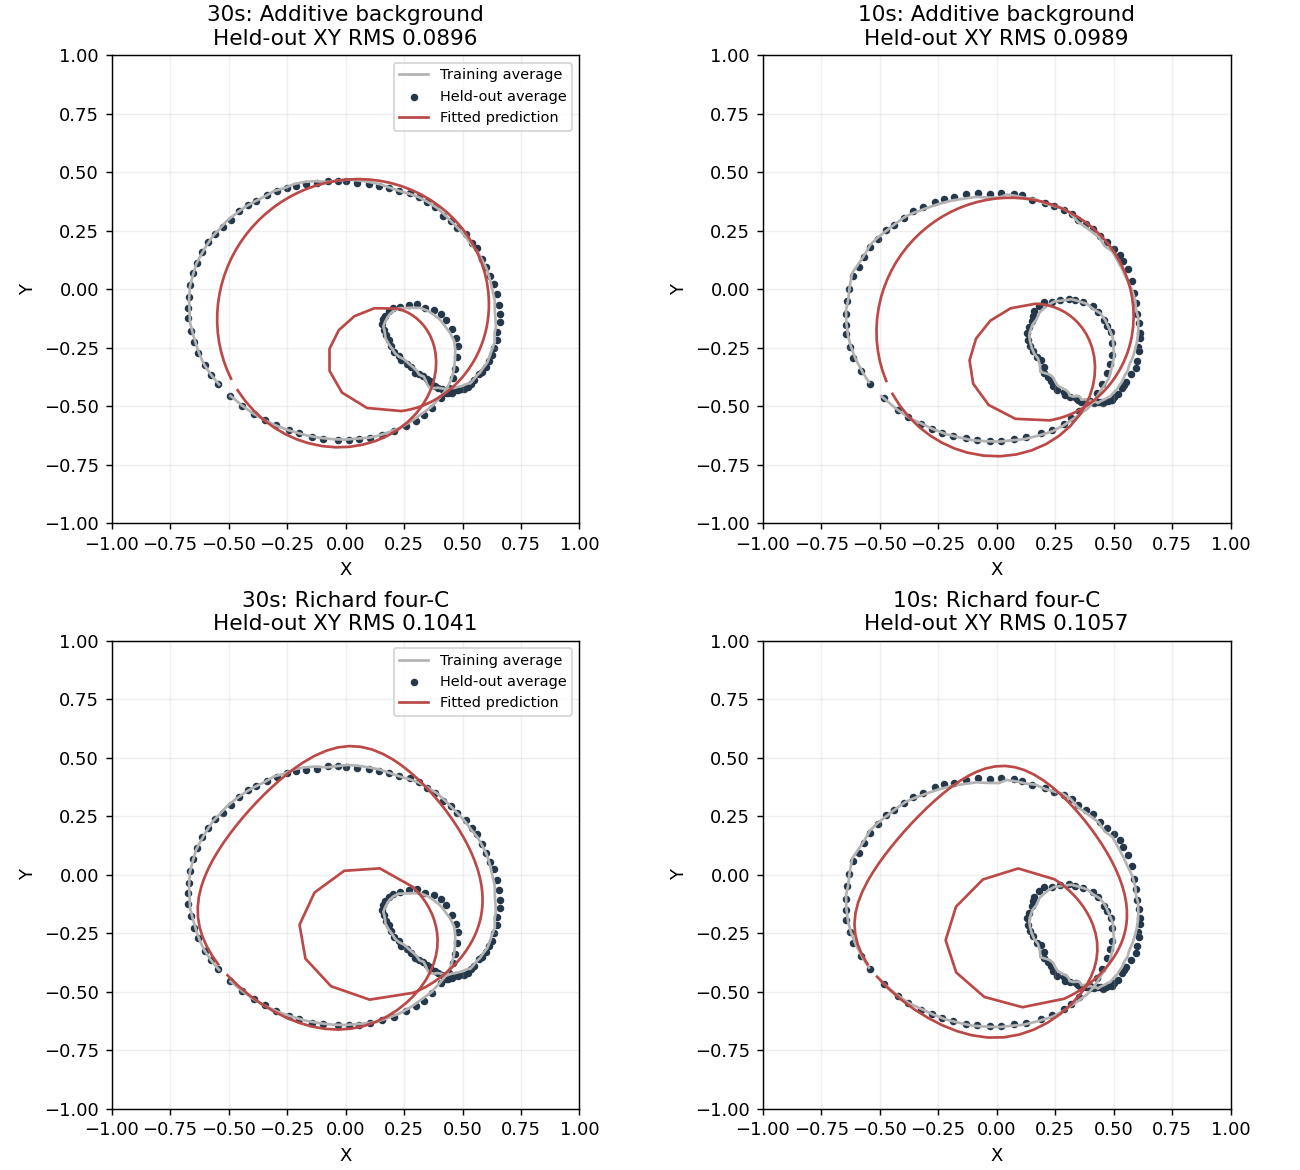

In [3]:
fig,axs=plt.subplots(2,2,figsize=(10,9),layout="constrained")
for col,key in enumerate(KEYS):
    train=np.array(DATA[key]["train"]);test=np.array(DATA[key]["test"])
    for row,model in enumerate(LABELS):
        ax=axs[row,col];r=RESULTS[key][model]
        ax.plot(*xy(train).T,color="0.7",label="Training average")
        ax.scatter(*xy(test).T,s=10,color="#24384a",label="Held-out average")
        ax.plot(*xy(r["pred"]).T,color="#ba4947",label="Fitted prediction")
        ax.set(xlim=(-1,1),ylim=(-1,1),xlabel="X",ylabel="Y",title=f'{key}: {LABELS[model]}\nHeld-out XY RMS {r["scores"]["xy_rms"]:.4f}')
        ax.set_aspect("equal");ax.grid(alpha=.2)
        if col==0:ax.legend(fontsize=8)
plt.show()


| Interval | Model | Held-out XY RMS | BG / measured Tmax | Folded θ range |
|---|---|---:|---:|---:|
| 30s | Additive background | 0.08961 | 31.74% | 37.27–89.22° |
| 30s | Richard four-C | 0.10412 | Not inferred | 36.64–72.02° |
| 10s | Additive background | 0.09894 | 34.62% | 41.95–89.95° |
| 10s | Richard four-C | 0.10573 | Not inferred | 40.16–71.43° |

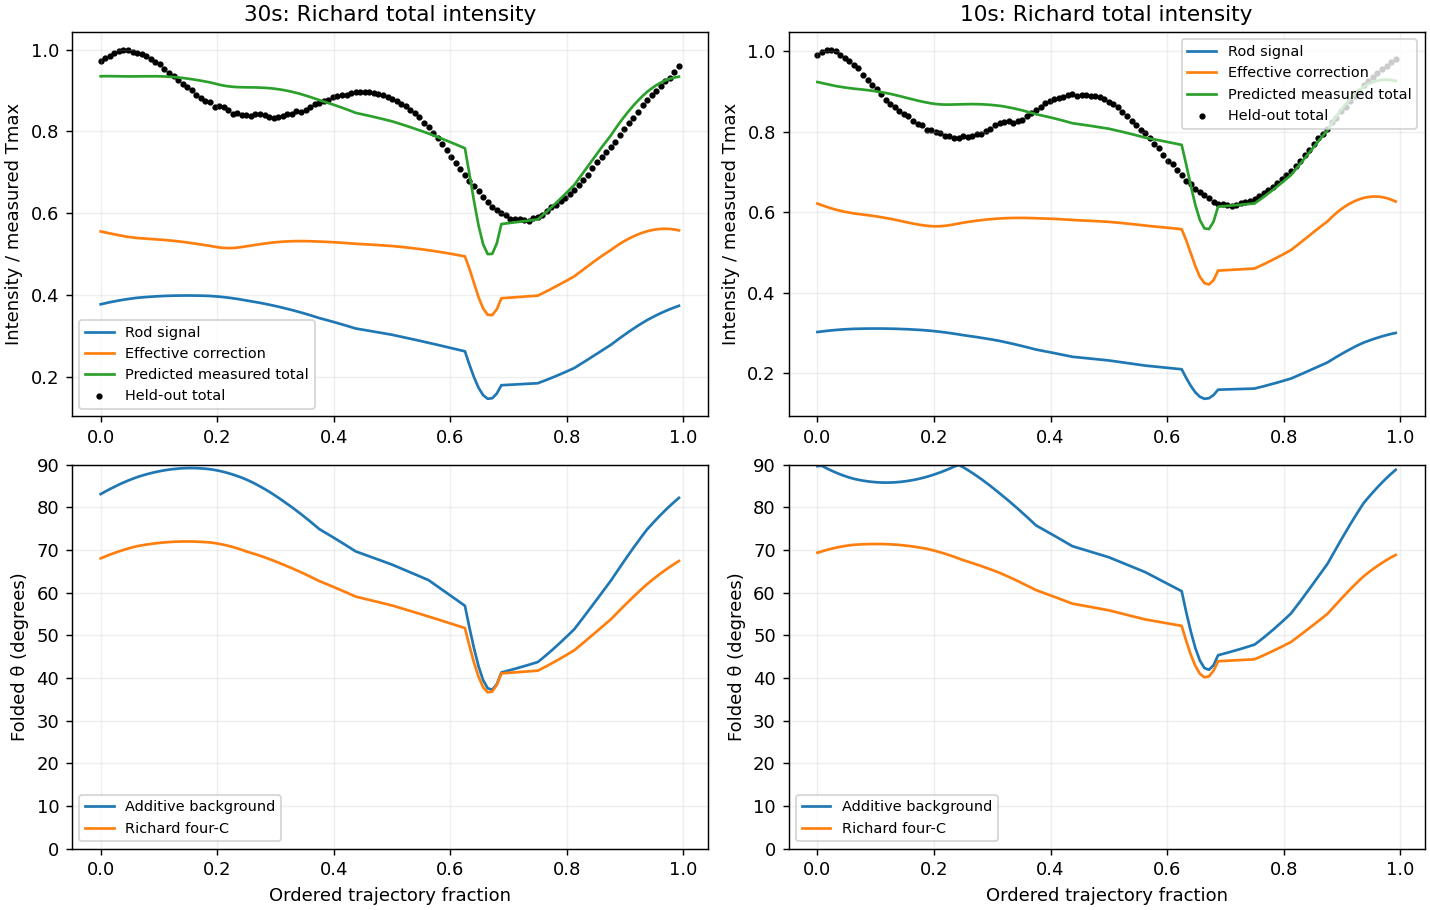

30s C [0°,90°,45°,135°], sqrt(original corrected intensity units): [0.613379 0.526826 0.394673 0.733122]
10s C [0°,90°,45°,135°], sqrt(original corrected intensity units): [0.764159 0.657529 0.477185 0.960405]


In [4]:
rows=["| Interval | Model | Held-out XY RMS | BG / measured Tmax | Folded θ range |", "|---|---|---:|---:|---:|"]
for key in KEYS:
    mx=np.array(DATA[key]["train"]).sum(0).max()
    for model in LABELS:
        r=RESULTS[key][model];th=r["theta"]
        bg=f'{100*r["bg"].sum()/mx:.2f}%' if model=="square" else "Not inferred"
        rows.append(f'| {key} | {LABELS[model]} | {r["scores"]["xy_rms"]:.5f} | {bg} | {th.min():.2f}–{th.max():.2f}° |')
display(Markdown("\n".join(rows)))
for key in KEYS:
    c=RESULTS[key]["richard4"]["p"][20:]*np.sqrt(SAVED[key]["richard4"]["scale"])
    print(key, "C [0°,90°,45°,135°], sqrt(original corrected intensity units):",np.round(c,6))
fig,axs=plt.subplots(2,2,figsize=(11,7),layout="constrained")
for col,key in enumerate(KEYS):
    f=np.arange(128)/128;mx=np.array(DATA[key]["train"]).sum(0).max()
    r=RESULTS[key]["richard4"]
    for term,label in [("signal","Rod signal"),("correction","Effective correction"),("pred","Predicted measured total")]:
        axs[0,col].plot(f,r[term].sum(0)/mx,label=label)
    axs[0,col].scatter(f,np.array(DATA[key]["test"]).sum(0)/mx,s=6,color="black",label="Held-out total")
    axs[0,col].set(title=key+": Richard total intensity",ylabel="Intensity / measured Tmax")
    for model in LABELS:axs[1,col].plot(f,RESULTS[key][model]["theta"],label=LABELS[model])
    axs[1,col].set(ylim=(0,90),xlabel="Ordered trajectory fraction",ylabel="Folded θ (degrees)")
for ax in axs.flat:ax.legend(fontsize=8);ax.grid(alpha=.2)
plt.show()


## Interpretation and optional refit

All four selected C values are positive; this was not imposed. They differ between intervals, which were fitted independently. A shared-C test has not been performed. The additive and four-C hypotheses recover different angle ranges; neither has independent angle ground truth. Richard's approximation leaves visible trajectory residuals in these data. That is a result of the hypothesis test, not a reason to quietly add extra parameters to it.

The saved fits used ten starting points per model and interval. The optional cell below performs one local restart from each saved optimum, and does not overwrite the saved reference results. It is disabled by default. Inputs are ordered cycle averages, not the raw 40-second recording; raw preprocessing remains in the processing pipeline.


In [5]:
RUN_REFIT=False
if RUN_REFIT:
    restarted={}
    for key in KEYS:
        train=np.array(DATA[key]["train"]);tm=train.sum(0).min()
        for model in LABELS:
            lo=np.r_[[.001,-np.pi,.001,-4*np.pi],[-4]*15,-8,[0,-1,-1] if model=="square" else [-np.inf]*4]
            hi=np.r_[[np.pi/2-.001,np.pi,np.pi/2-.001,4*np.pi],[4]*15,4,[.95,1,1] if model=="square" else [np.inf]*4]
            fit=least_squares(residual,RESULTS[key][model]["p"],args=(model,train,tm),bounds=(lo,hi),max_nfev=700,ftol=2e-9,xtol=2e-9,gtol=2e-9,x_scale="jac")
            restarted[key,model]=fit
            print(key,model,"converged:",fit.success,"mean squared residual:",np.mean(fit.fun**2))
